In [82]:
from __future__ import annotations
#importing required libraries
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import sklearn 
import onnx


import warnings
warnings.filterwarnings('ignore')

# checking versions
print('numpy')
!pip3 show numpy|grep -i ^Version:
print('pandas')
!pip3 show pandas|grep -i ^Version:
print('seaborn')
!pip3 show seaborn|grep -i ^Version:
print('matplotlib')
!pip3 show matplotlib|grep -i ^Version:
print("sklearn")
!pip3 show scikit-learn|grep -i ^Version:
print('Onnx')
!pip3 show onnx|grep -i ^Version:

numpy
Version: 2.0.2
pandas
Version: 2.3.3
seaborn
Version: 0.13.2
matplotlib
Version: 3.10.0
sklearn
Version: 1.6.1
Onnx
Version: 1.22.0


In [83]:
##importing current dataset 
#importing required libraries
import pandas as pd
import numpy as np

import os 
import sys

# path='/home/dreams/Projects/DataScienceProjects/MachineLearningProject/IntroductionMachineLearning/dataset/spotifyTrackingDataset'
fullPath='/kaggle/input/datasets/maharshipandya/-spotify-tracks-dataset/dataset.csv'

if os.path.exists(fullPath):
    dataset=pd.read_csv(fullPath,engine='python',on_bad_lines='skip')
    # dataset=reduce_mem_usage(dataset)
    
else:
    raise Exception("Couldn't find path")


In [84]:
# data wrangling current dataset
# dataset.head()
dataset.drop(columns=['track_id','time_signature','Unnamed: 0'],inplace=True)
dataset.head()
# dataset.info()
# dataset.describe()

,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,track_genre
0,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,acoustic
1,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,acoustic
2,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,acoustic
3,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,acoustic
4,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,acoustic


In [85]:
#output count of observations 
dataset.shape[0]

114000

In [86]:
#converting current np.int64 columns to np.float64
intColumns=dataset.select_dtypes(np.int64).columns

dataset[intColumns]=dataset[intColumns].astype(np.float64)
# dataset[intColumns]

In [87]:
#converting duration_ms to seconds
dataset['duration_s']=dataset['duration_ms']/60
dataset.drop(columns=['duration_ms'],inplace=True)

In [88]:
#removing Nan from dataset
dataset.dropna(inplace=True,axis=0)

In [89]:
#checking NaN values
dataset.isna().sum()

artists             0
album_name          0
track_name          0
popularity          0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
track_genre         0
duration_s          0
dtype: int64

In [90]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 113999 entries, 0 to 113999
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   artists           113999 non-null  object 
 1   album_name        113999 non-null  object 
 2   track_name        113999 non-null  object 
 3   popularity        113999 non-null  float64
 4   explicit          113999 non-null  bool   
 5   danceability      113999 non-null  float64
 6   energy            113999 non-null  float64
 7   key               113999 non-null  float64
 8   loudness          113999 non-null  float64
 9   mode              113999 non-null  float64
 10  speechiness       113999 non-null  float64
 11  acousticness      113999 non-null  float64
 12  instrumentalness  113999 non-null  float64
 13  liveness          113999 non-null  float64
 14  valence           113999 non-null  float64
 15  tempo             113999 non-null  float64
 16  track_genre       113999 

In [91]:
any(dataset.explicit) #returns True

True

In [92]:
# label encoding for bool features
boolFeatures=dataset.select_dtypes(np.bool).columns

#importing required libraries 
from sklearn.preprocessing import LabelEncoder

encoder=LabelEncoder()
encodedVersion=encoder.fit_transform(dataset[boolFeatures])

dataset=dataset.assign(explicit=encodedVersion)

dataset[boolFeatures]




,explicit
0,0
1,0
2,0
3,0
4,0
...,...
113995,0
113996,0
113997,0
113998,0


In [93]:
#fixing some staff
import pandas as pd
import numpy as np

# dataset.track_name.str.replace('infinity (888) - feat. Joey Bada$$','infinity (888) - feat. Joey Badass')
# dataset[dataset.track_name=='infinity (888) - feat. Joey Bada$$']

dataset.replace('infinity (888) - feat. Joey Bada$$','infinity (888) - feat. Joey Badass')

,artists,album_name,track_name,popularity,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,track_genre,duration_s
0,Gen Hoshino,Comedy,Comedy,73.0,0,0.676,0.4610,1.0,-6.746,0.0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,acoustic,3844.433333
1,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55.0,0,0.420,0.1660,1.0,-17.235,1.0,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,acoustic,2493.500000
2,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57.0,0,0.438,0.3590,0.0,-9.734,1.0,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,acoustic,3513.766667
3,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71.0,0,0.266,0.0596,0.0,-18.515,1.0,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,acoustic,3365.550000
4,Chord Overstreet,Hold On,Hold On,82.0,0,0.618,0.4430,2.0,-9.681,1.0,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,acoustic,3314.216667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21.0,0,0.172,0.2350,5.0,-16.393,1.0,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,world-music,6416.650000
113996,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22.0,0,0.174,0.1170,0.0,-18.318,0.0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,world-music,6416.666667
113997,Cesária Evora,Best Of,Miss Perfumado,22.0,0,0.629,0.3290,0.0,-10.895,0.0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,world-music,4524.433333
113998,Michael W. Smith,Change Your World,Friends,41.0,0,0.587,0.5060,7.0,-10.889,1.0,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,world-music,4731.550000


In [94]:
import pandas as pd
dataset.replace('XXXTENTACION;Joey Bada$$','XXXTENTACION;Joey Badass')

,artists,album_name,track_name,popularity,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,track_genre,duration_s
0,Gen Hoshino,Comedy,Comedy,73.0,0,0.676,0.4610,1.0,-6.746,0.0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,acoustic,3844.433333
1,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55.0,0,0.420,0.1660,1.0,-17.235,1.0,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,acoustic,2493.500000
2,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57.0,0,0.438,0.3590,0.0,-9.734,1.0,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,acoustic,3513.766667
3,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71.0,0,0.266,0.0596,0.0,-18.515,1.0,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,acoustic,3365.550000
4,Chord Overstreet,Hold On,Hold On,82.0,0,0.618,0.4430,2.0,-9.681,1.0,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,acoustic,3314.216667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21.0,0,0.172,0.2350,5.0,-16.393,1.0,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,world-music,6416.650000
113996,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22.0,0,0.174,0.1170,0.0,-18.318,0.0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,world-music,6416.666667
113997,Cesária Evora,Best Of,Miss Perfumado,22.0,0,0.629,0.3290,0.0,-10.895,0.0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,world-music,4524.433333
113998,Michael W. Smith,Change Your World,Friends,41.0,0,0.587,0.5060,7.0,-10.889,1.0,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,world-music,4731.550000


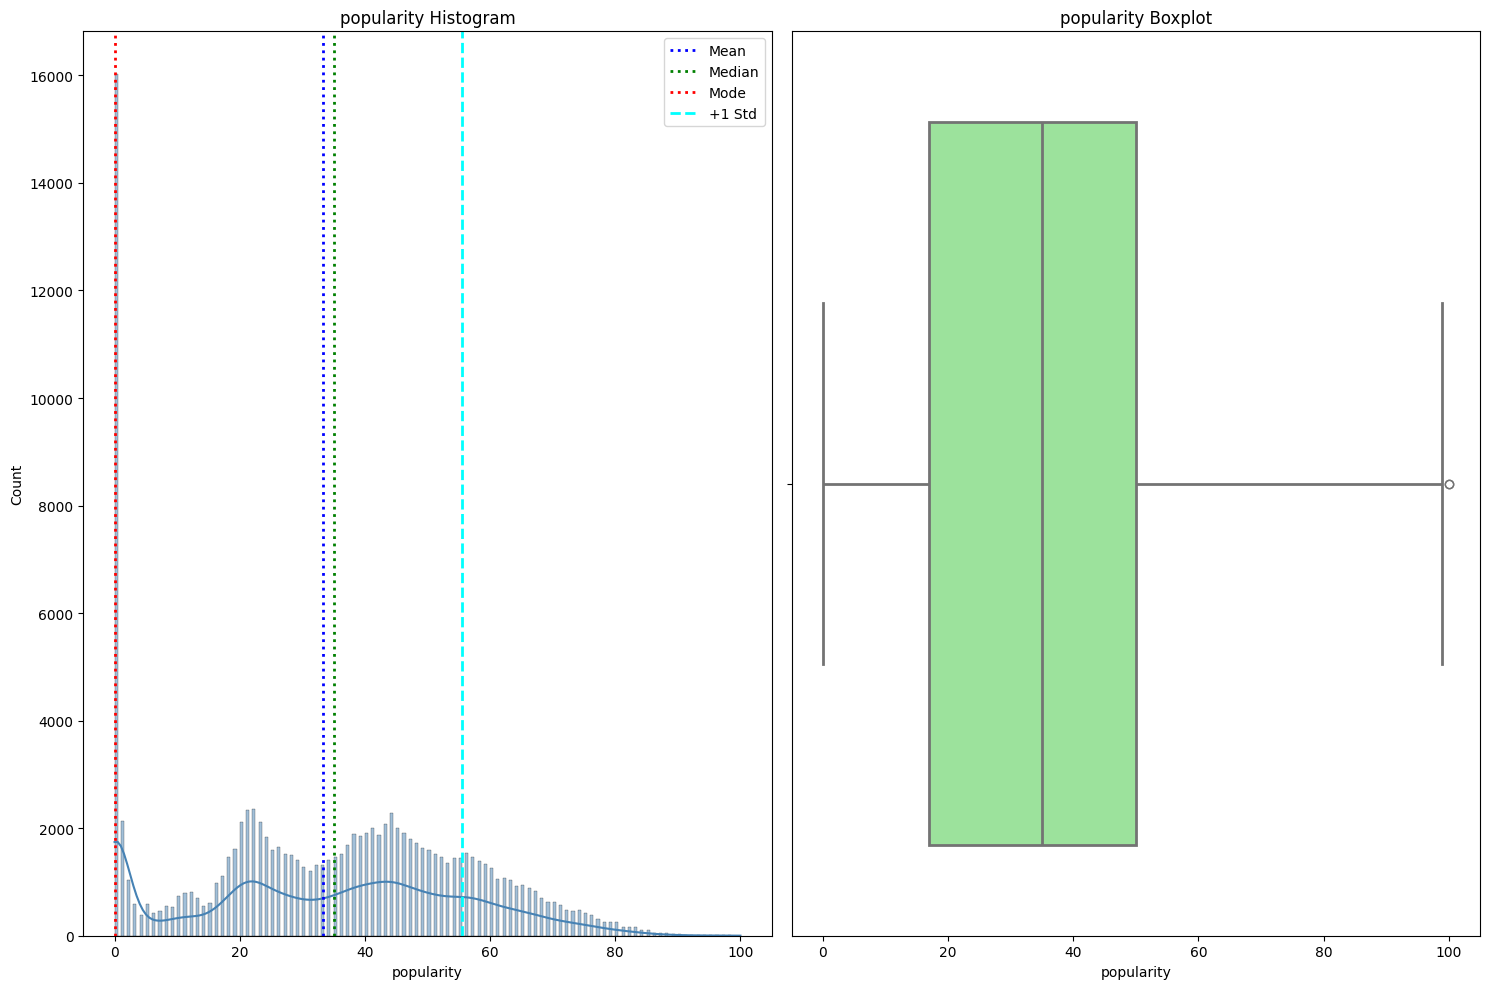

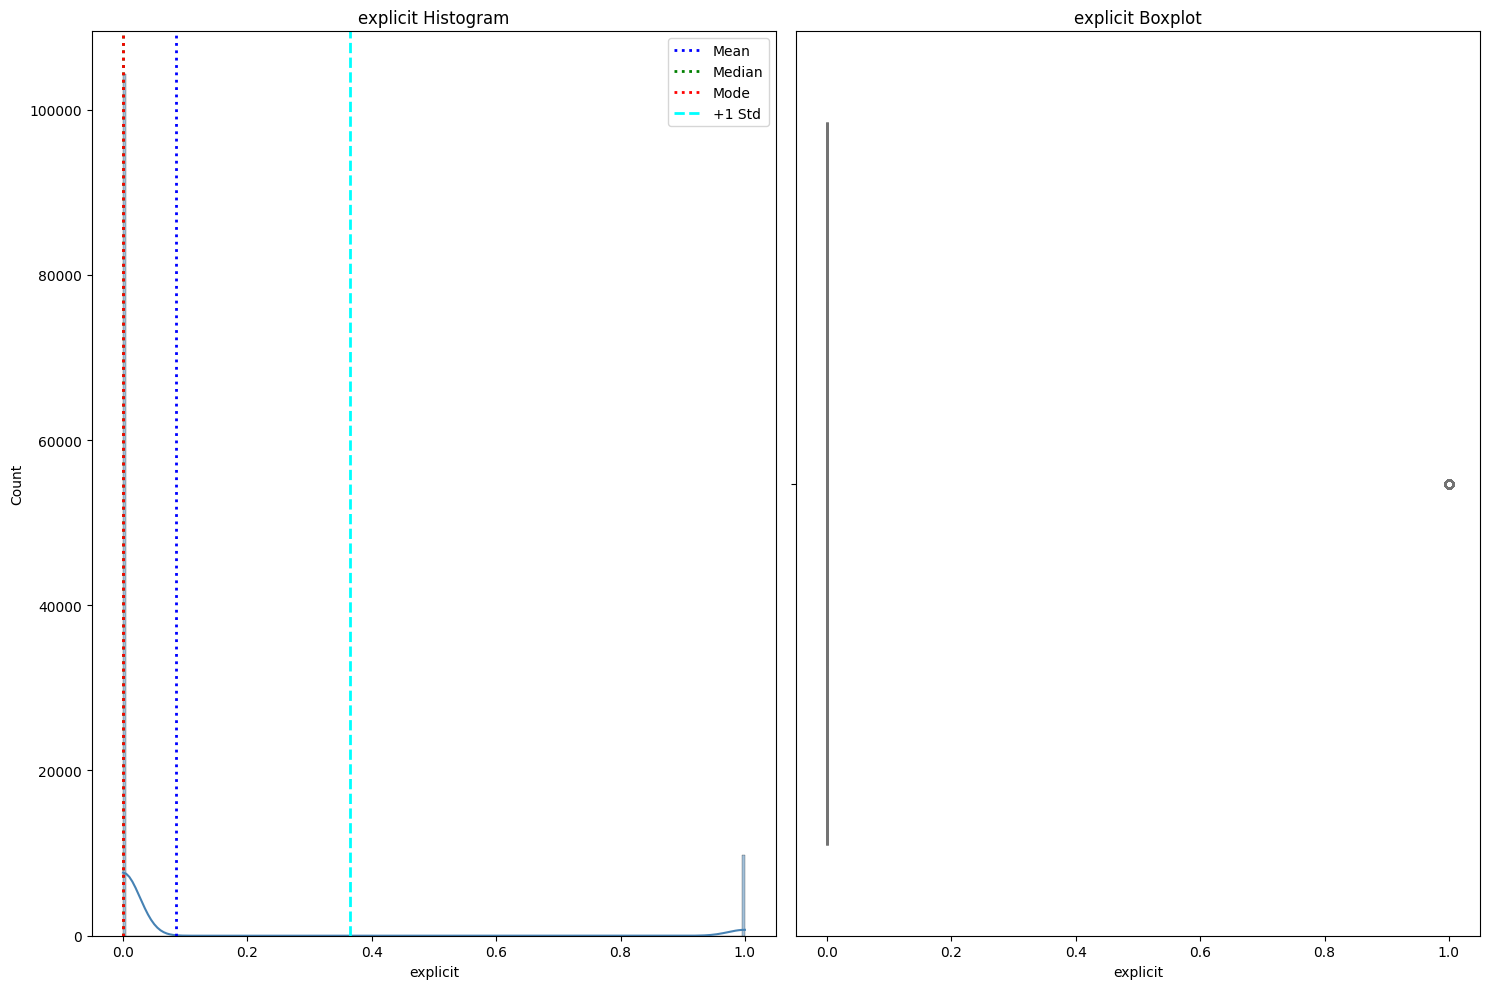

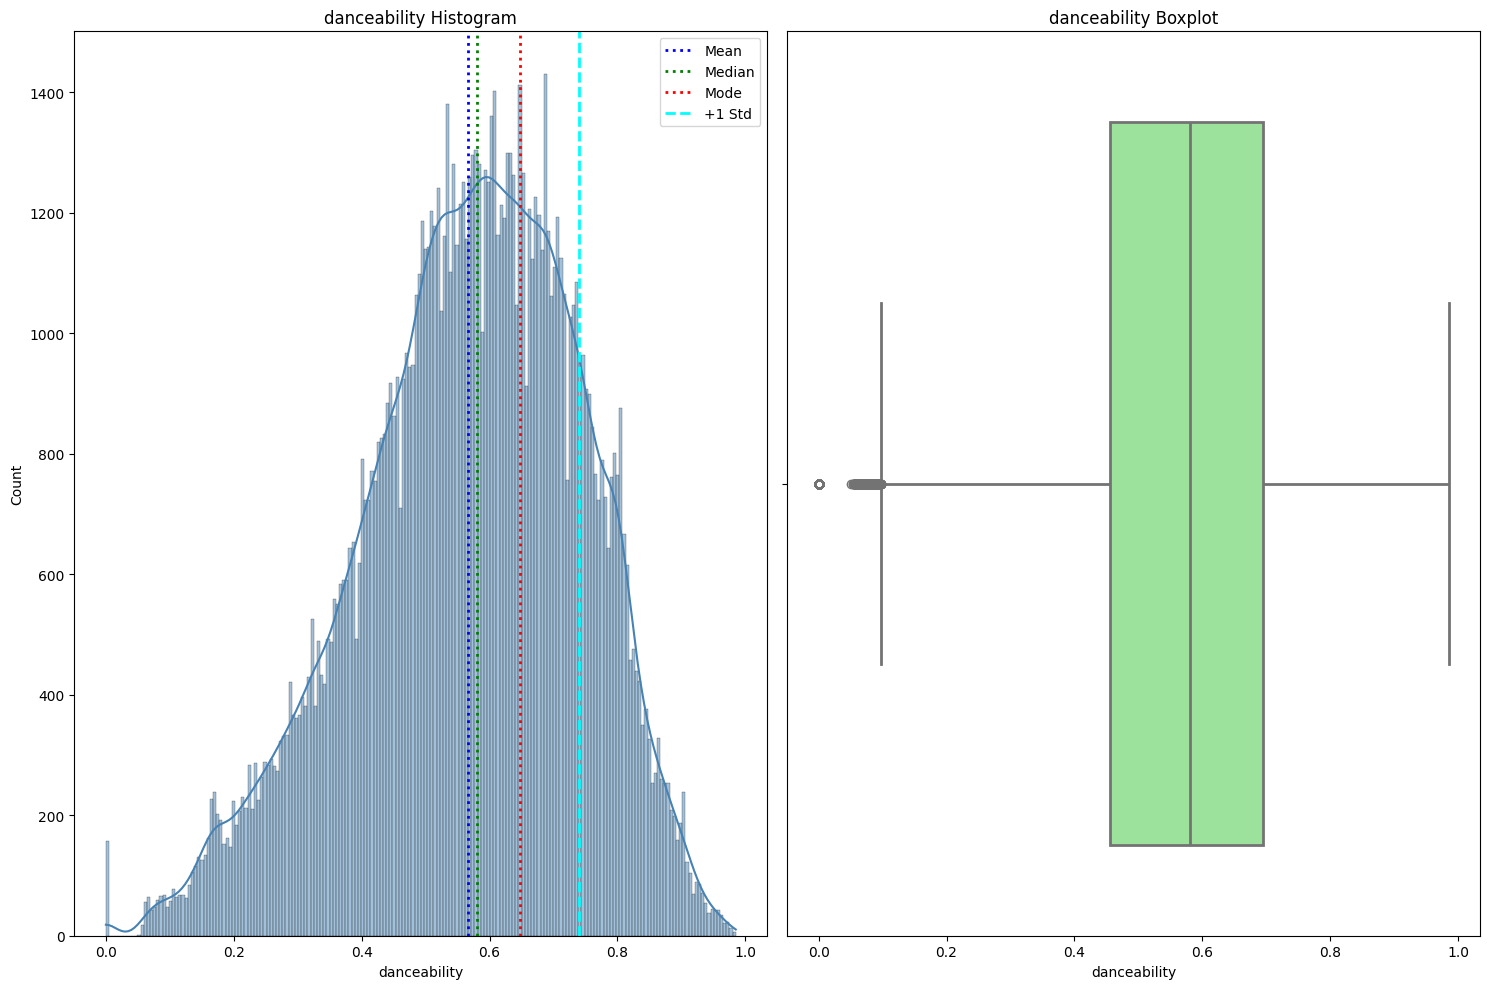

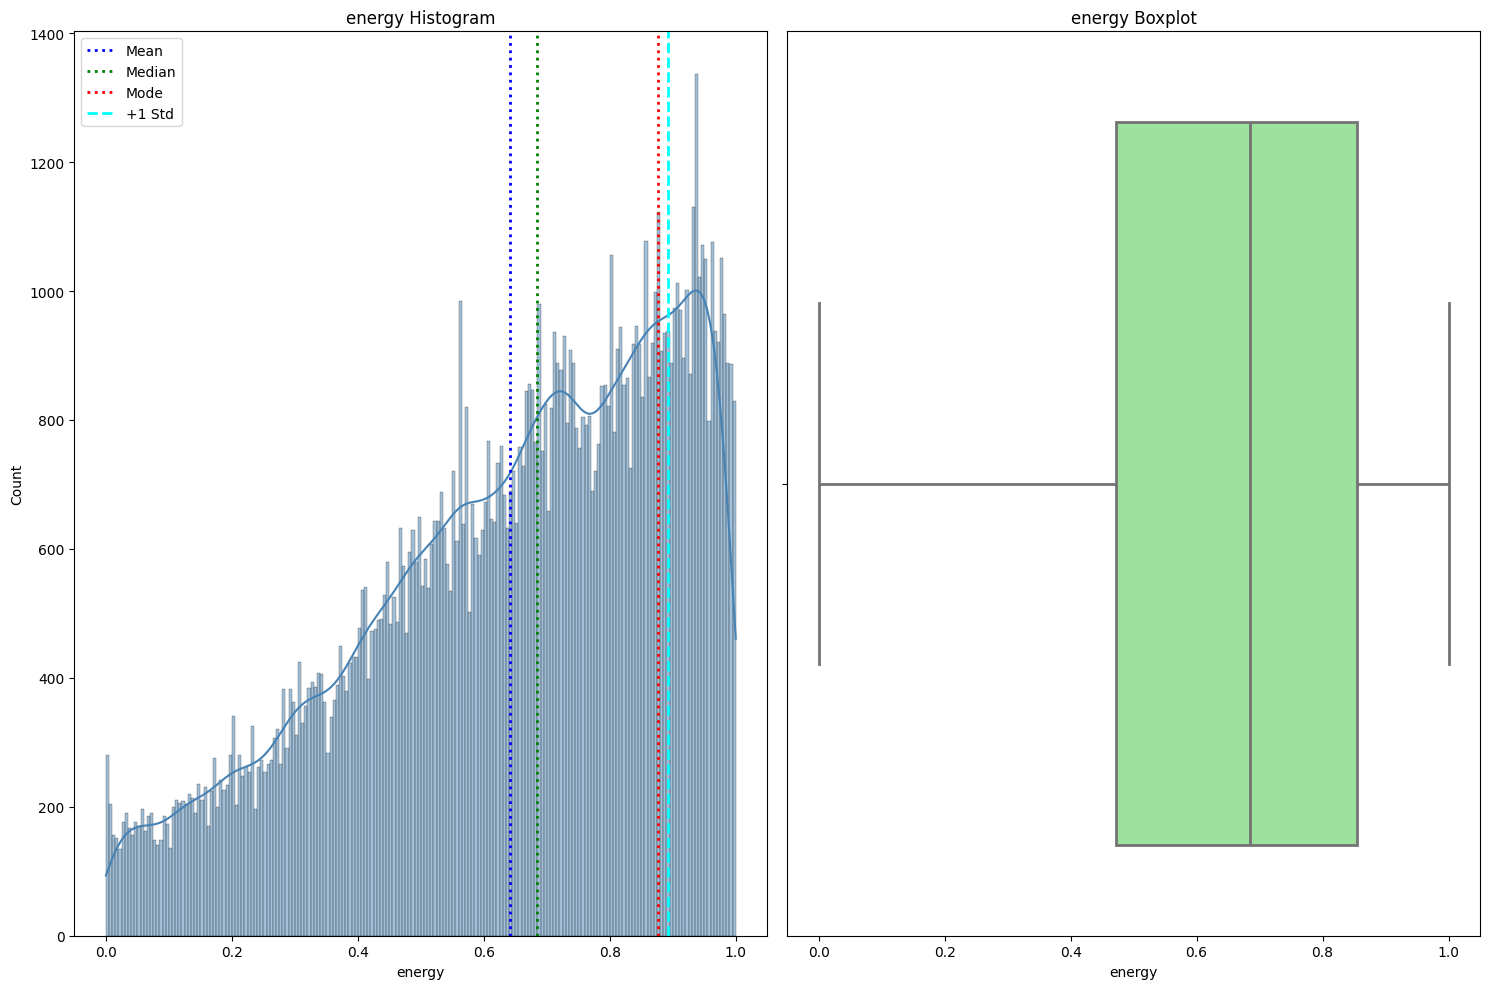

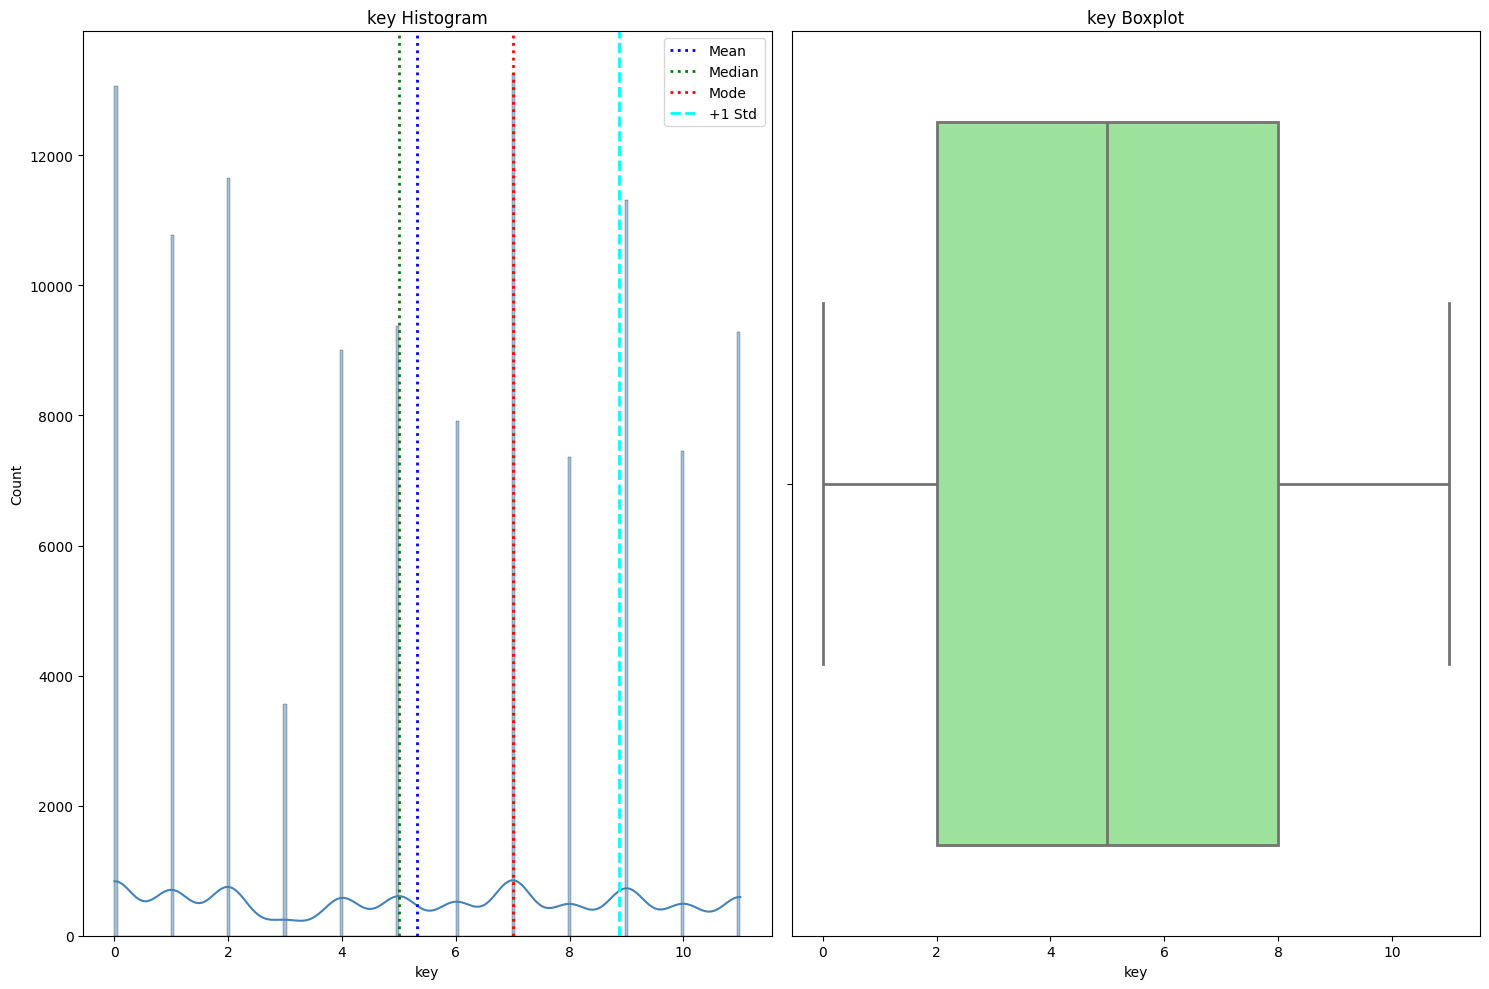

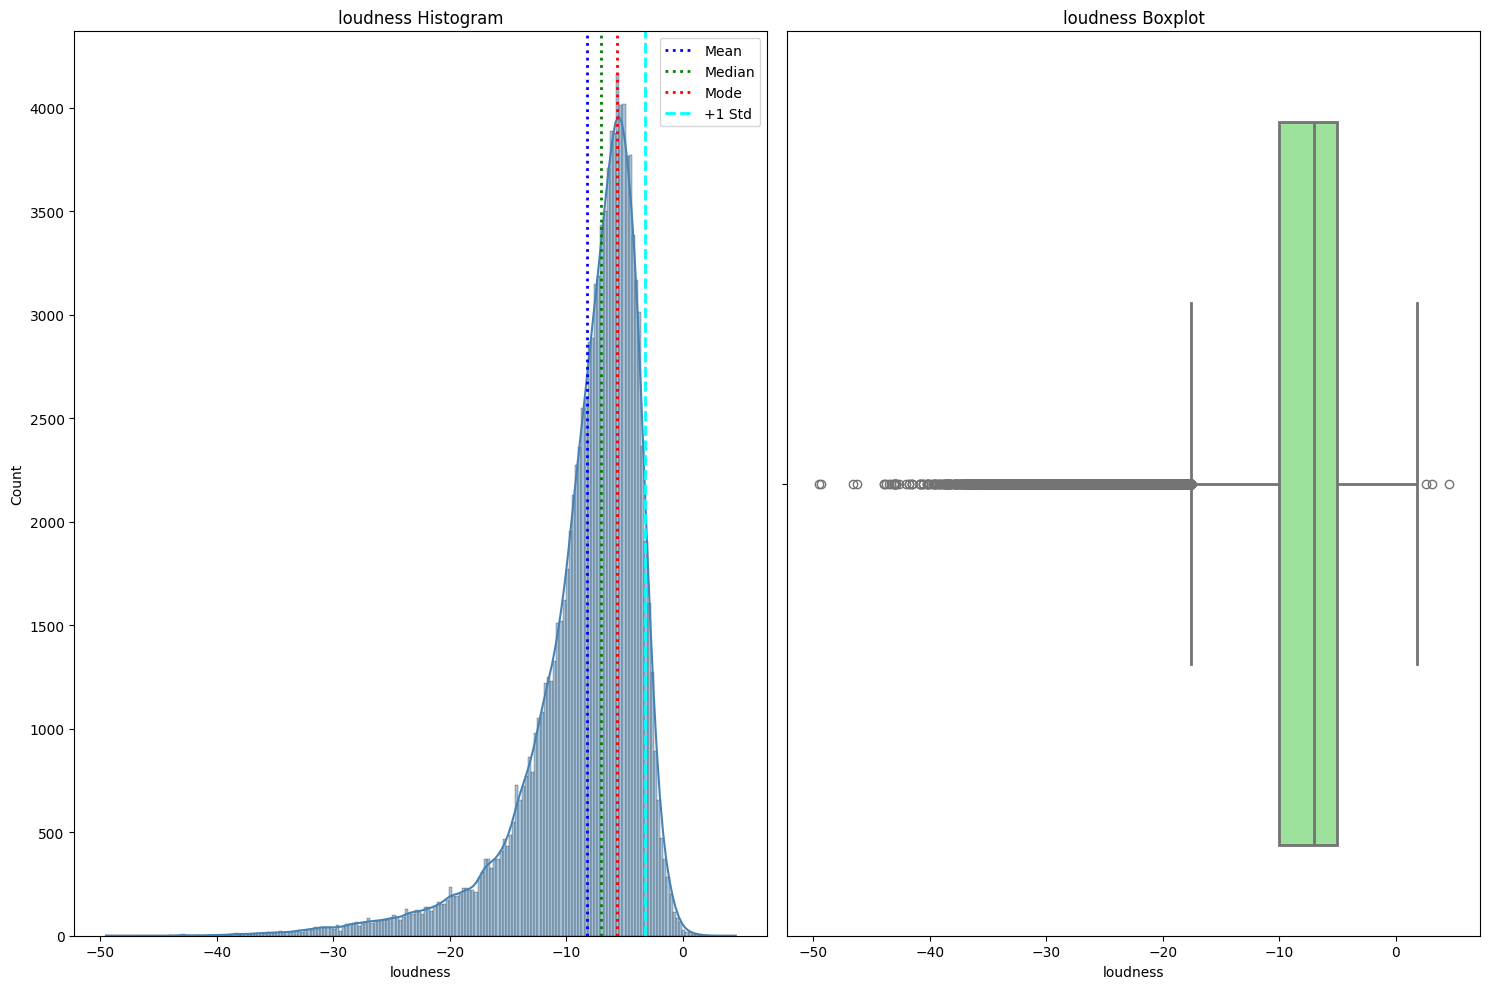

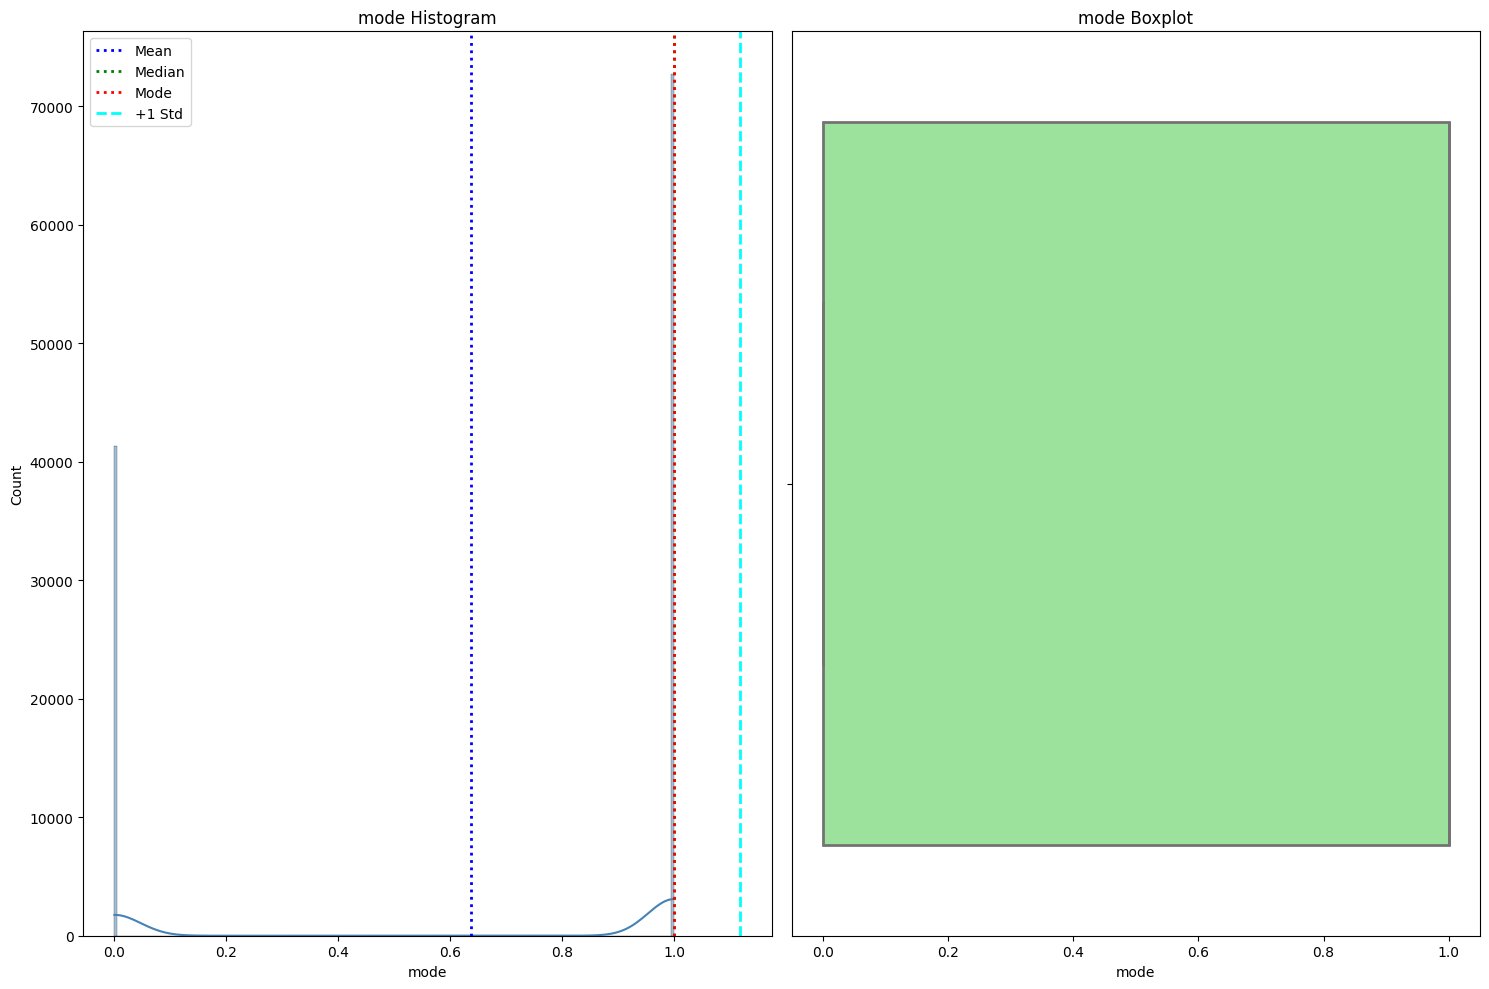

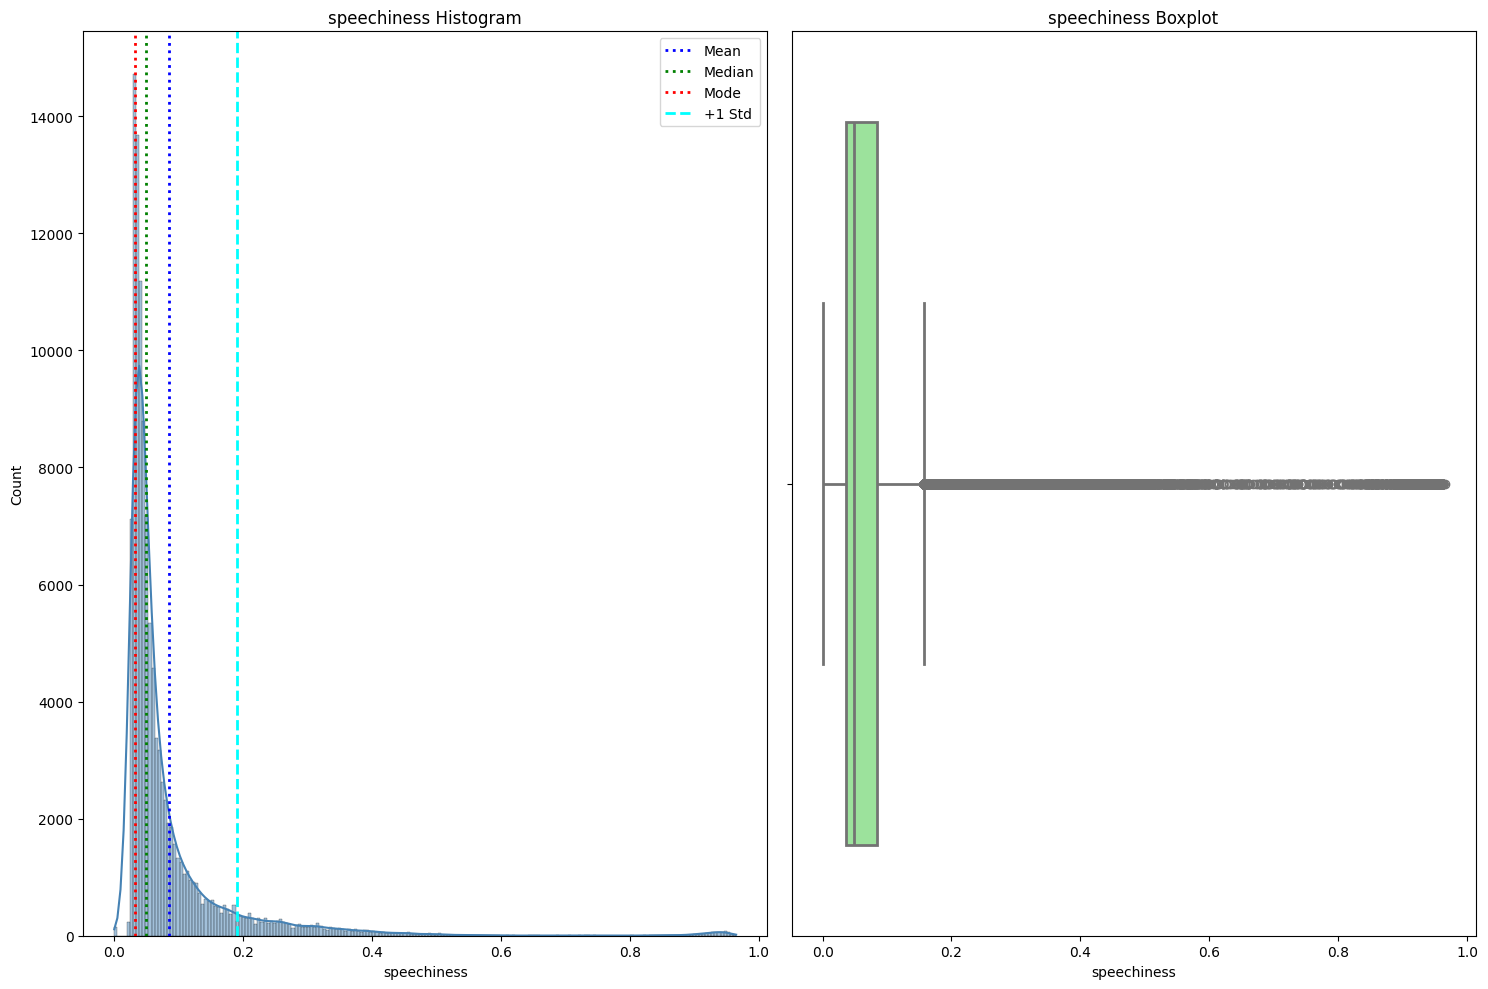

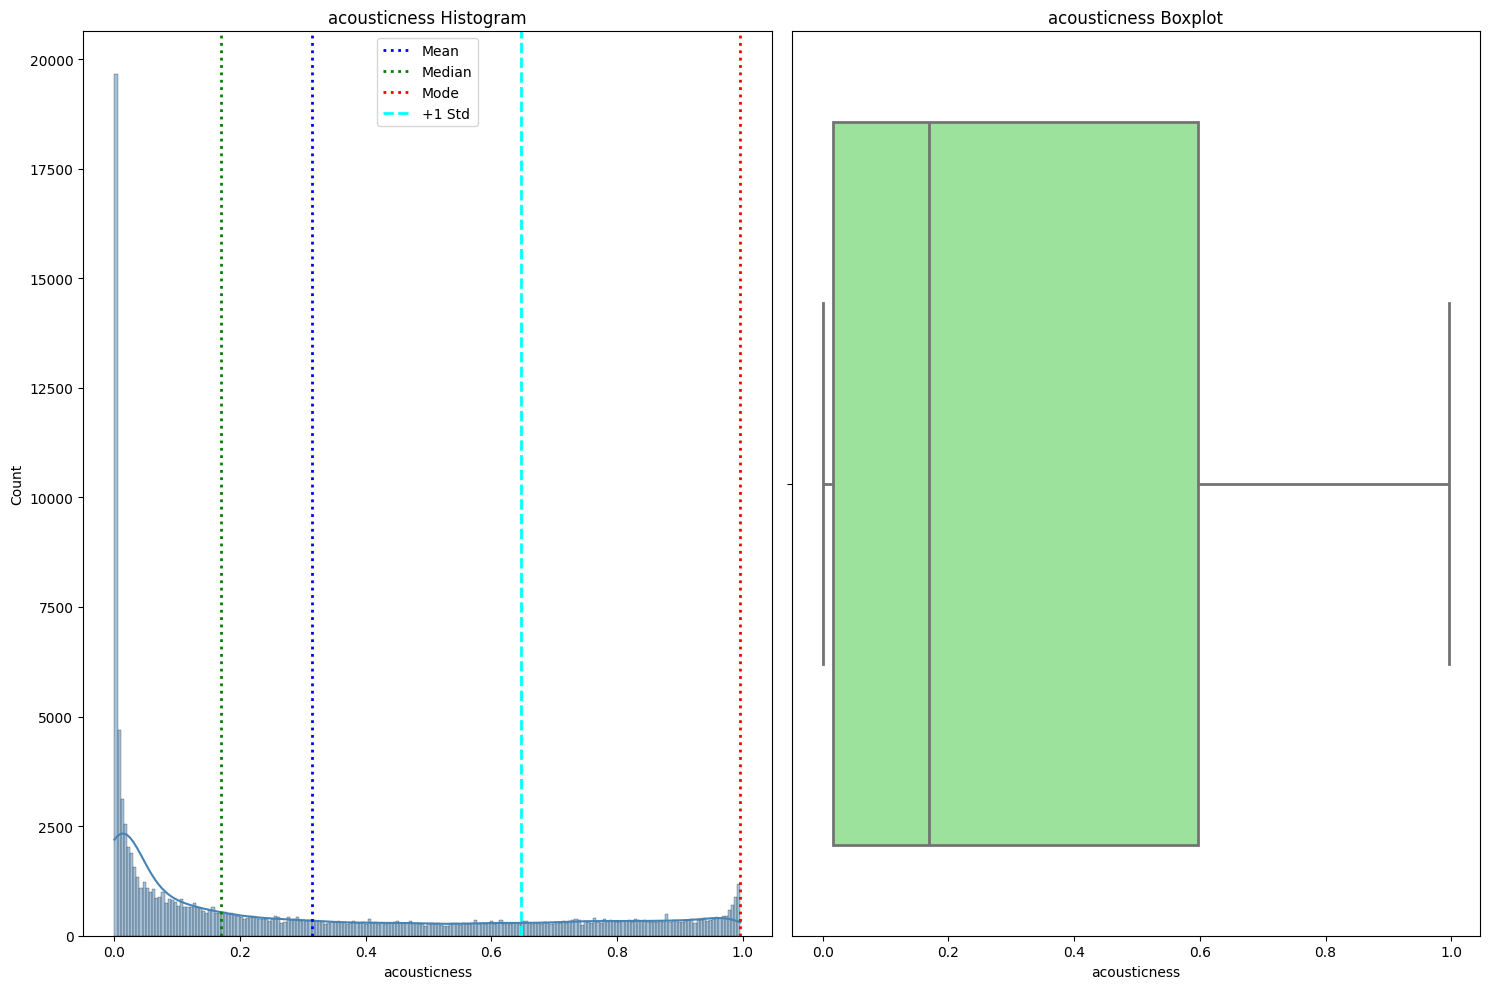

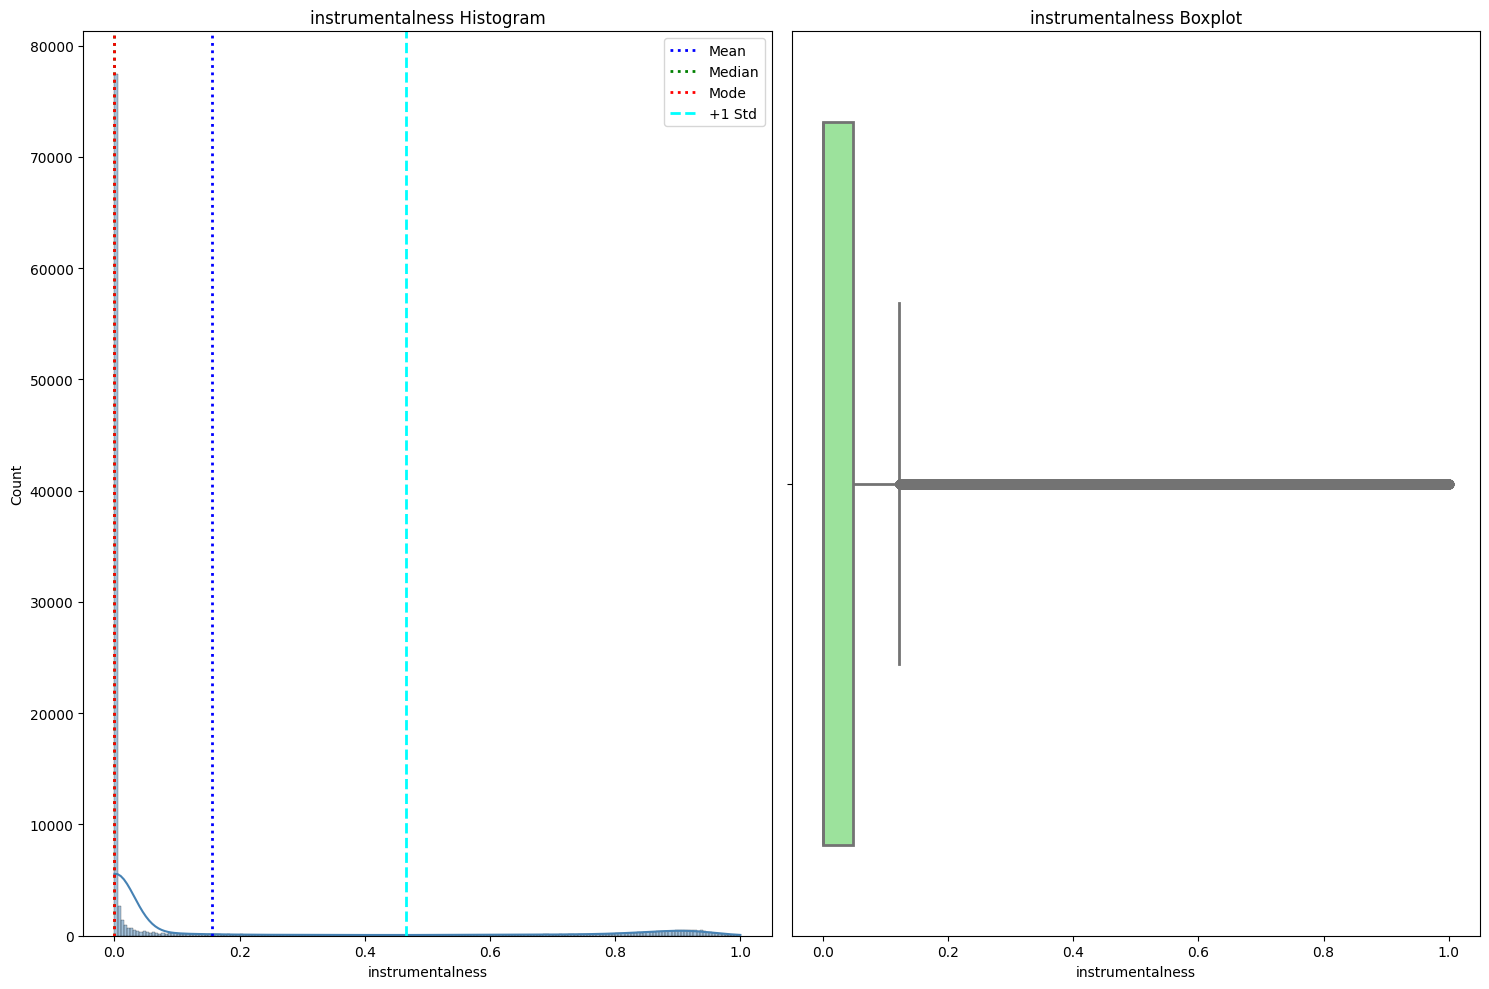

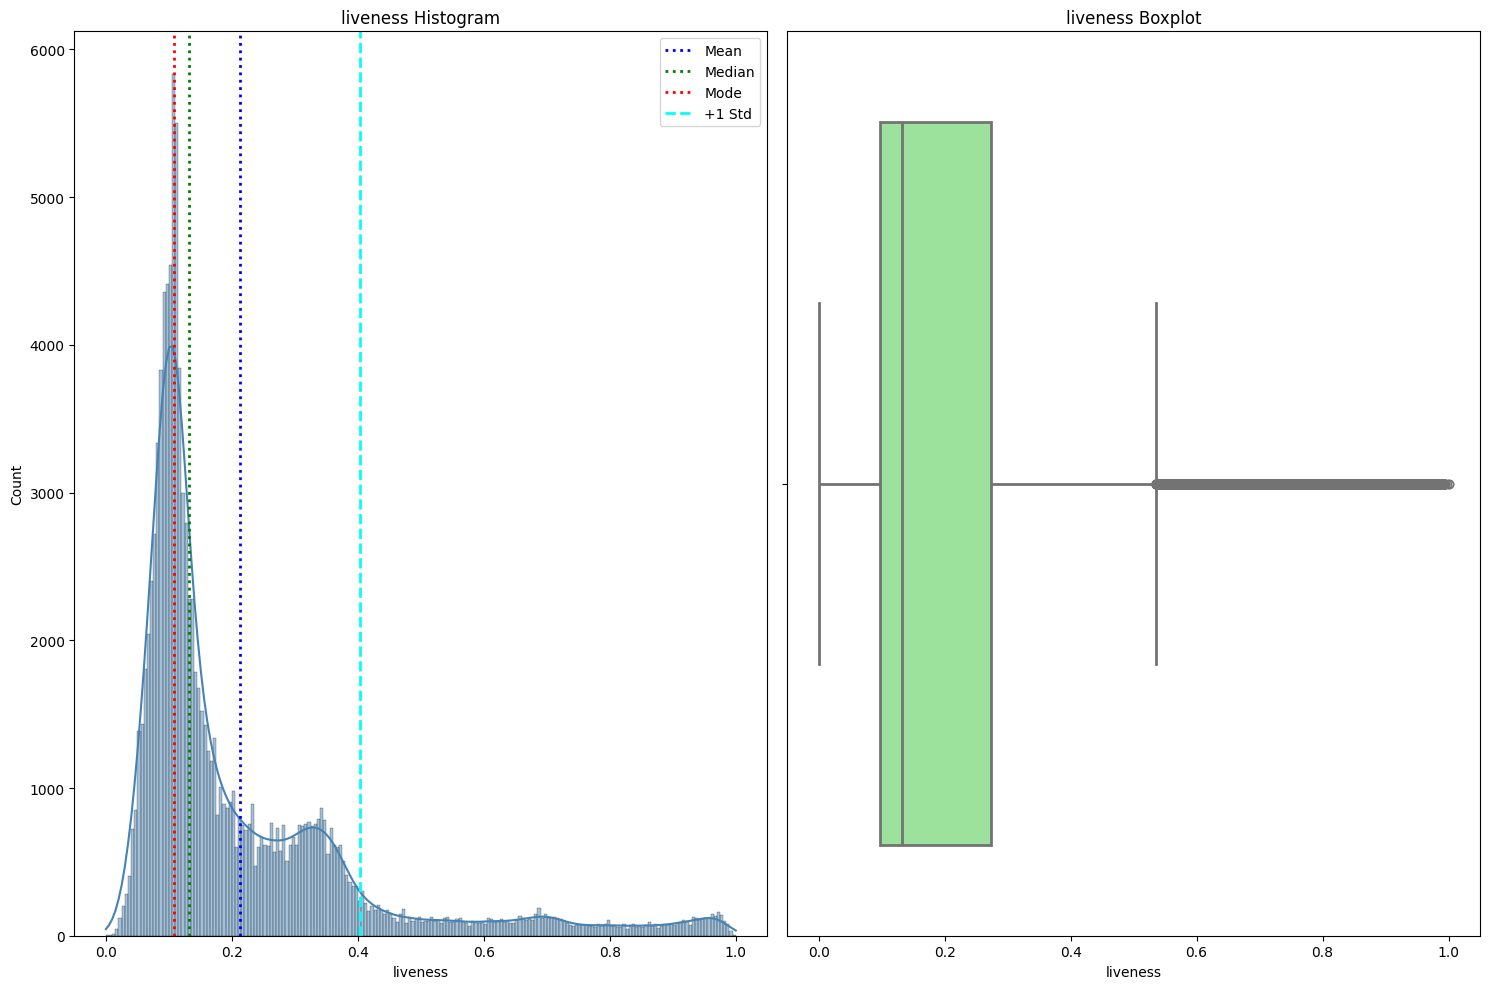

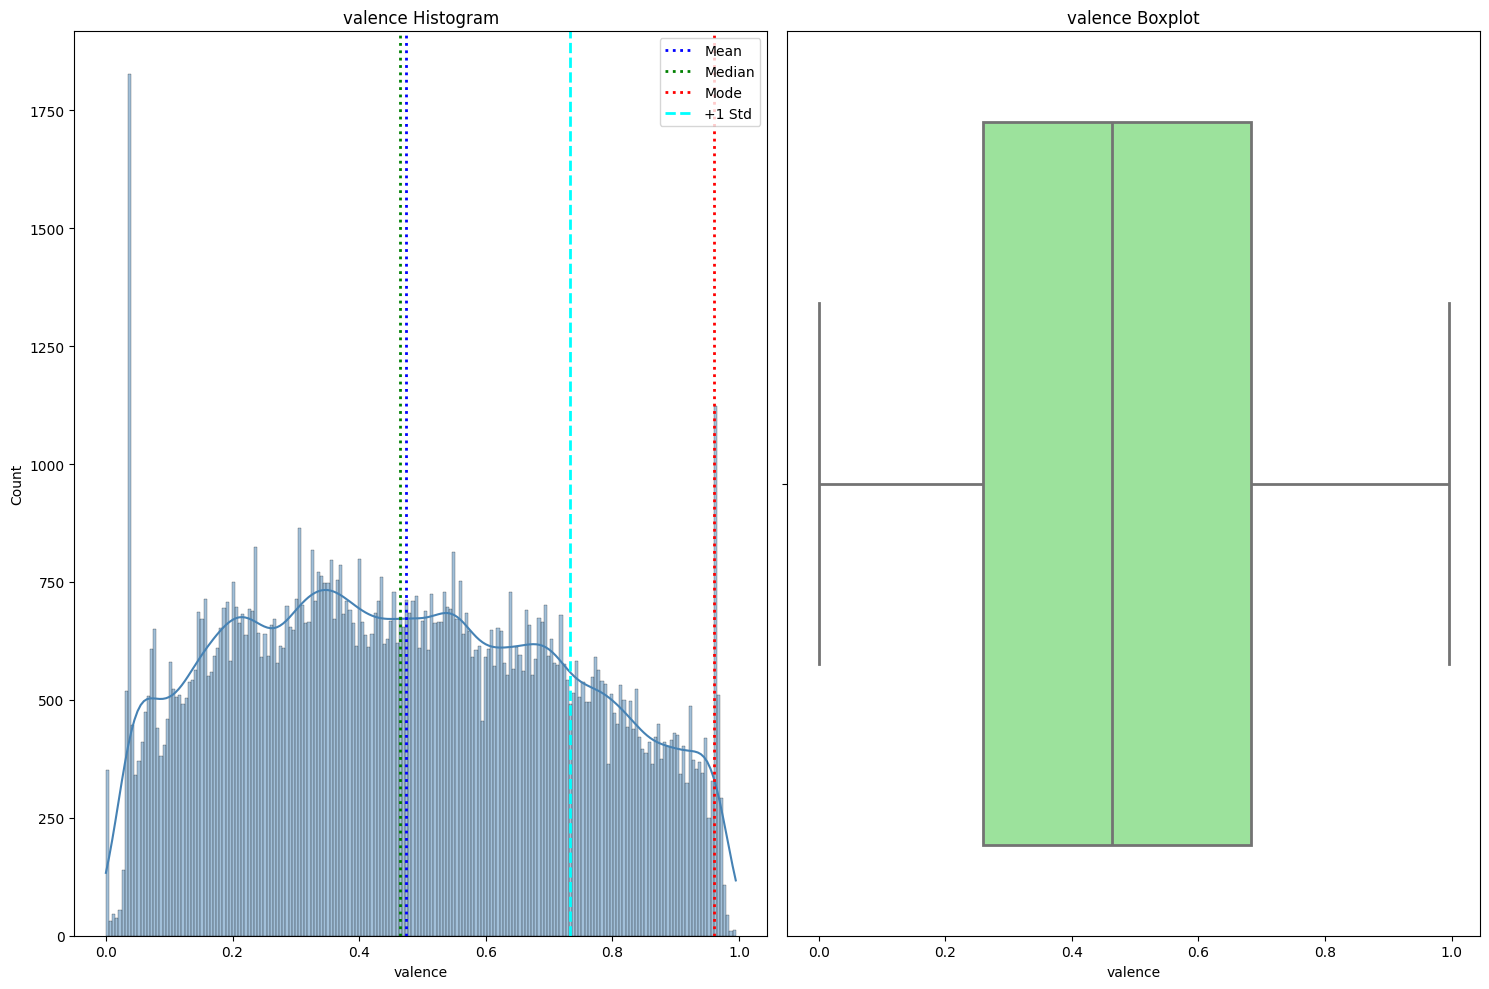

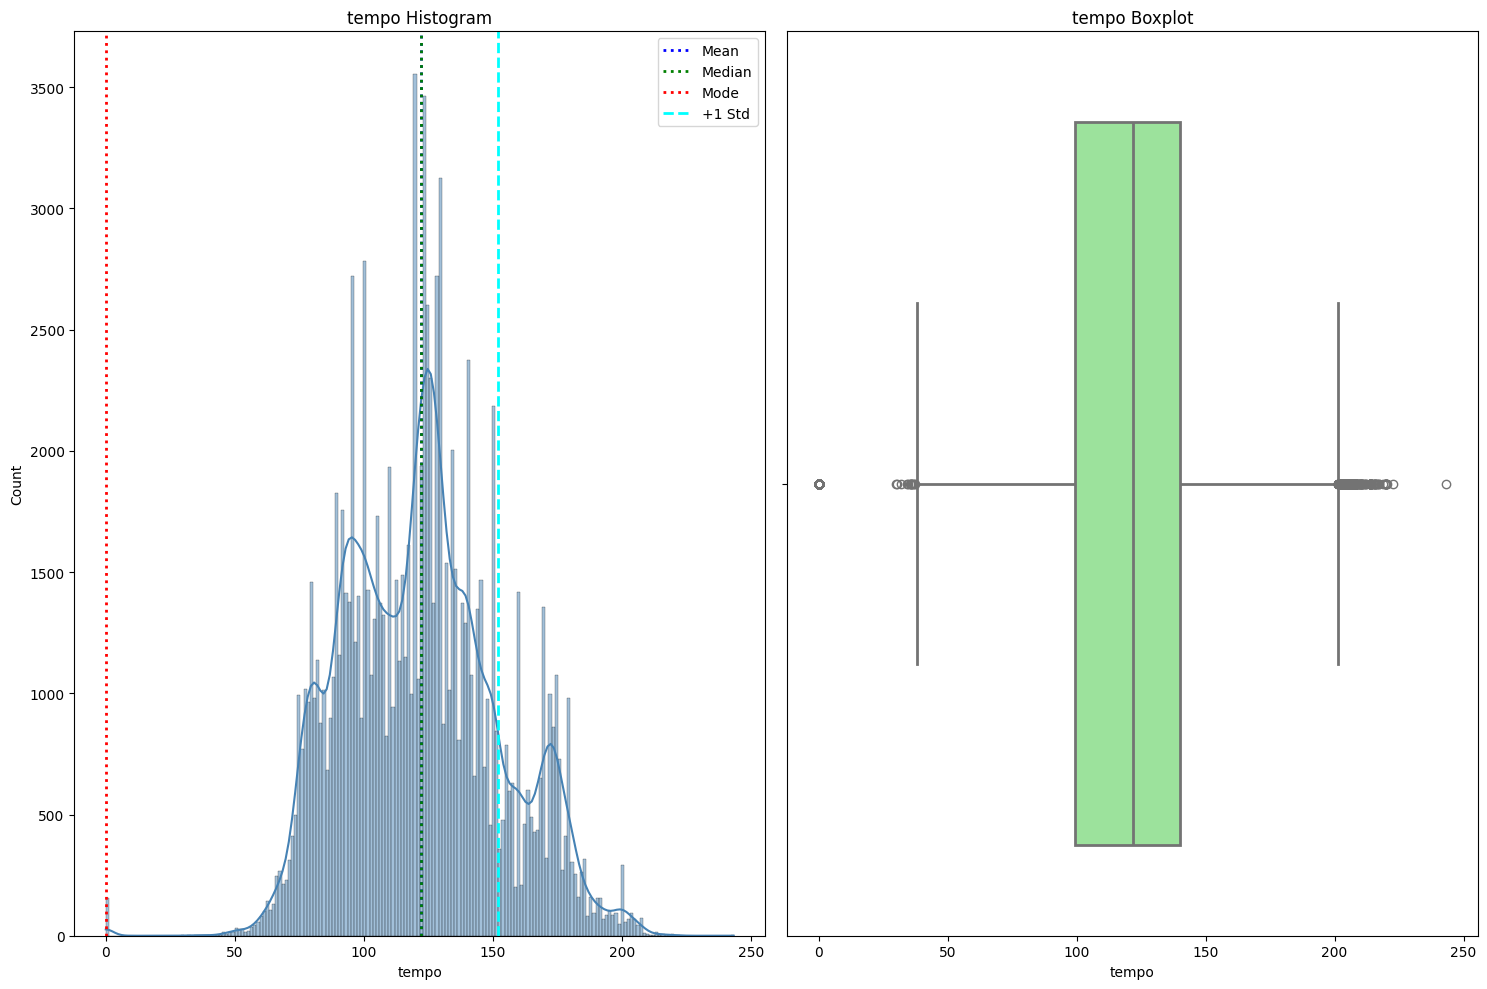

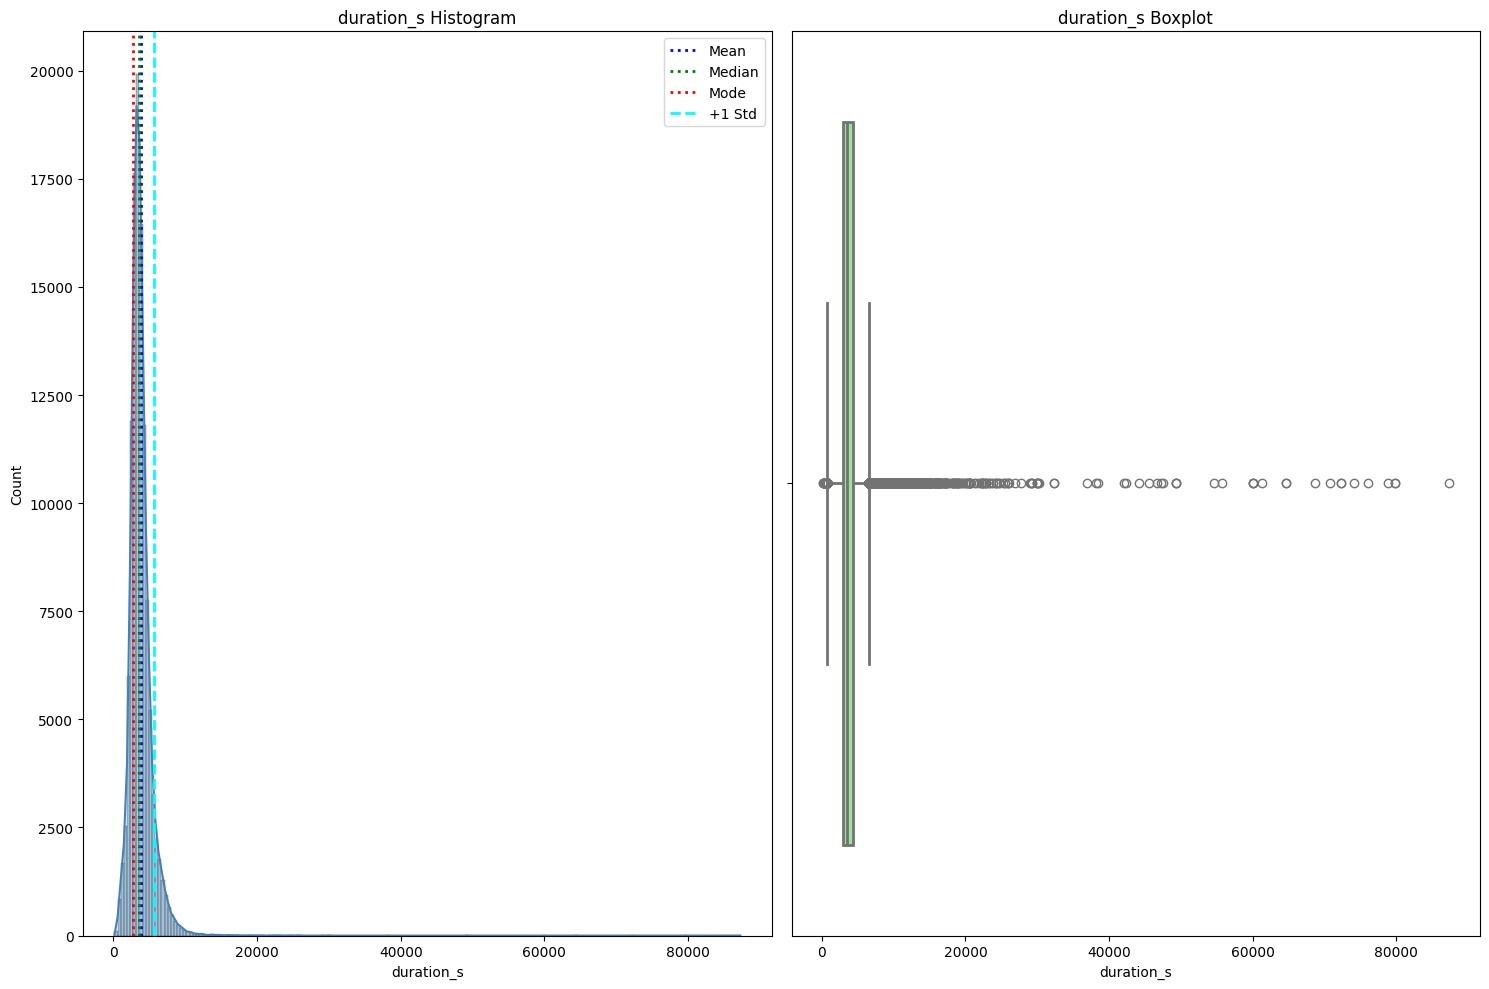

In [95]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns
features = dataset.select_dtypes(include=[np.number]).columns

for feature in features:

    fig, axes = plt.subplots(1, 2, figsize=(15, 10))

    # Histogram
    sns.histplot(
        dataset[feature],
        bins=200,
        kde=True,
        color="steelblue",
        ax=axes[0]
    )

    #mean
    axes[0].axvline(
        dataset[feature].mean(),
        color="blue",
        linestyle=":",
        linewidth=2,
        label="Mean"
    )

    #median
    axes[0].axvline(
        dataset[feature].median(),
        color='green',
        linestyle=':',
        linewidth=2,
        label='Median'
    )

    #mode
    axes[0].axvline(
        dataset[feature].mode()[0],
        color='red',
        linestyle=':',
        linewidth=2,
        label='Mode'
        )

    axes[0].axvline(
        dataset[feature].mean() + dataset[feature].std(),
        color="aqua",
        linestyle="--",
        linewidth=2,
        label="+1 Std"
    )

    axes[0].set_title(f"{feature} Histogram")
    axes[0].set_xlabel(feature)
    axes[0].set_ylabel("Count")
    axes[0].legend()

    # Boxplot
    sns.boxplot(
        x=dataset[feature],
        color="lightgreen",
        linewidth=2,
        ax=axes[1],
    )

    axes[1].set_title(f"{feature} Boxplot")
    axes[1].set_xlabel(feature)

    plt.tight_layout()
    plt.show()

<Axes: >

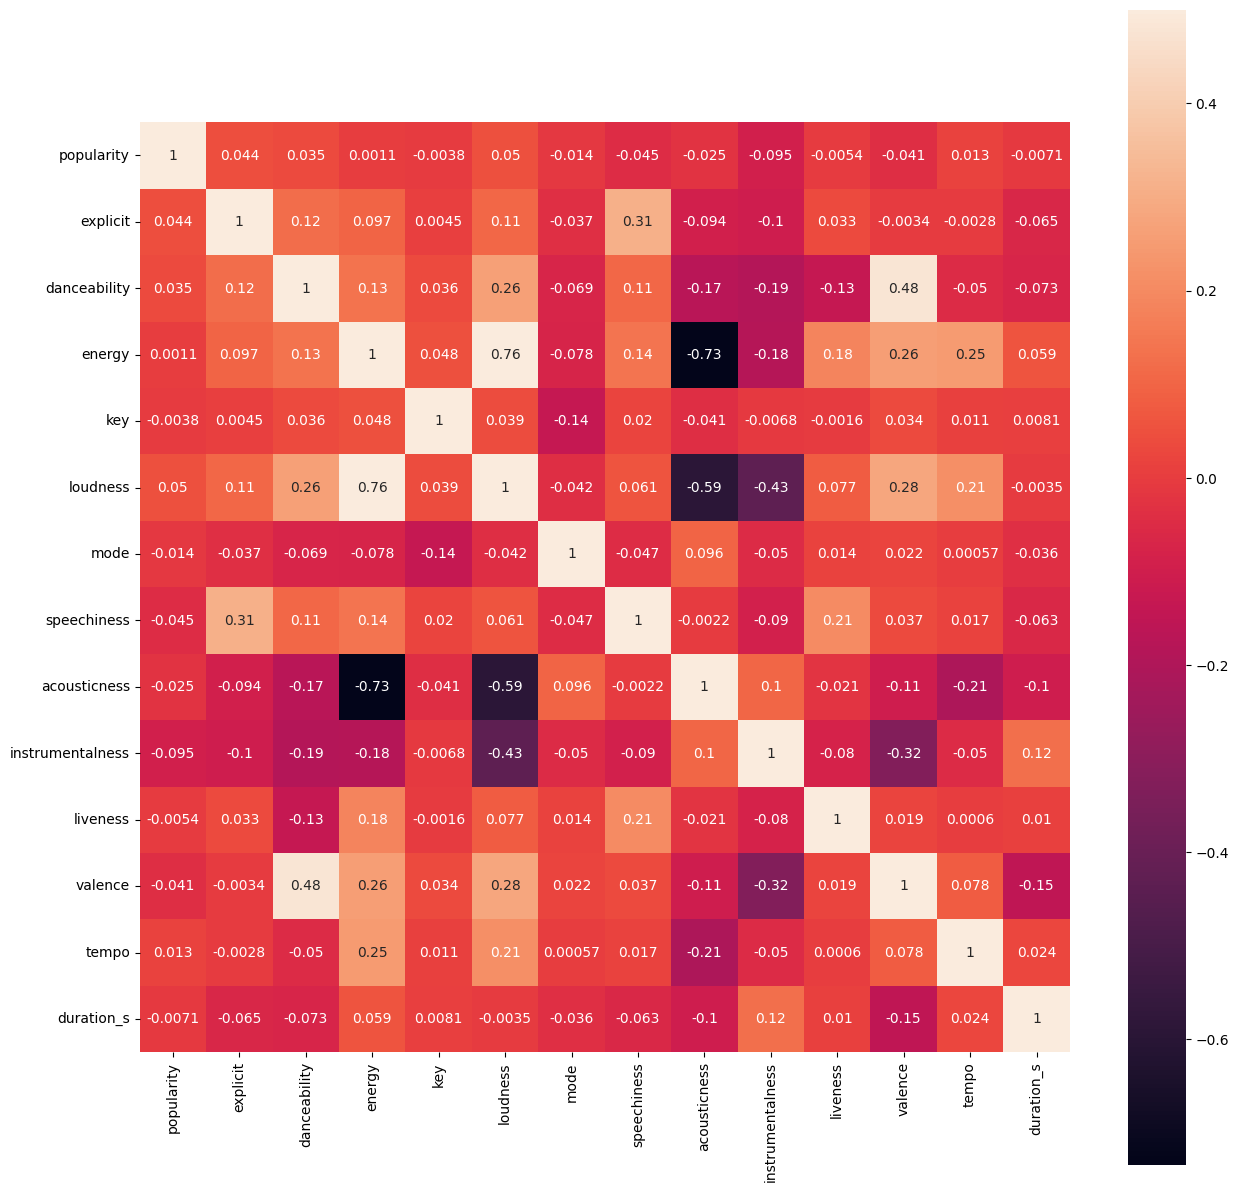

In [96]:
##Analyzing categorical features (creating correlation heat map)
#importing required libraries
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

#setting config
sns.set_palette('Set2')
plt.figure(figsize=(15,15))

categoricalFeatures=dataset.select_dtypes(np.object_).columns
numericals=dataset.drop(columns=categoricalFeatures)


corrNumericals=dataset.corr(numeric_only=True)


sns.heatmap(corrNumericals,vmax=.5,annot=True,square=True)

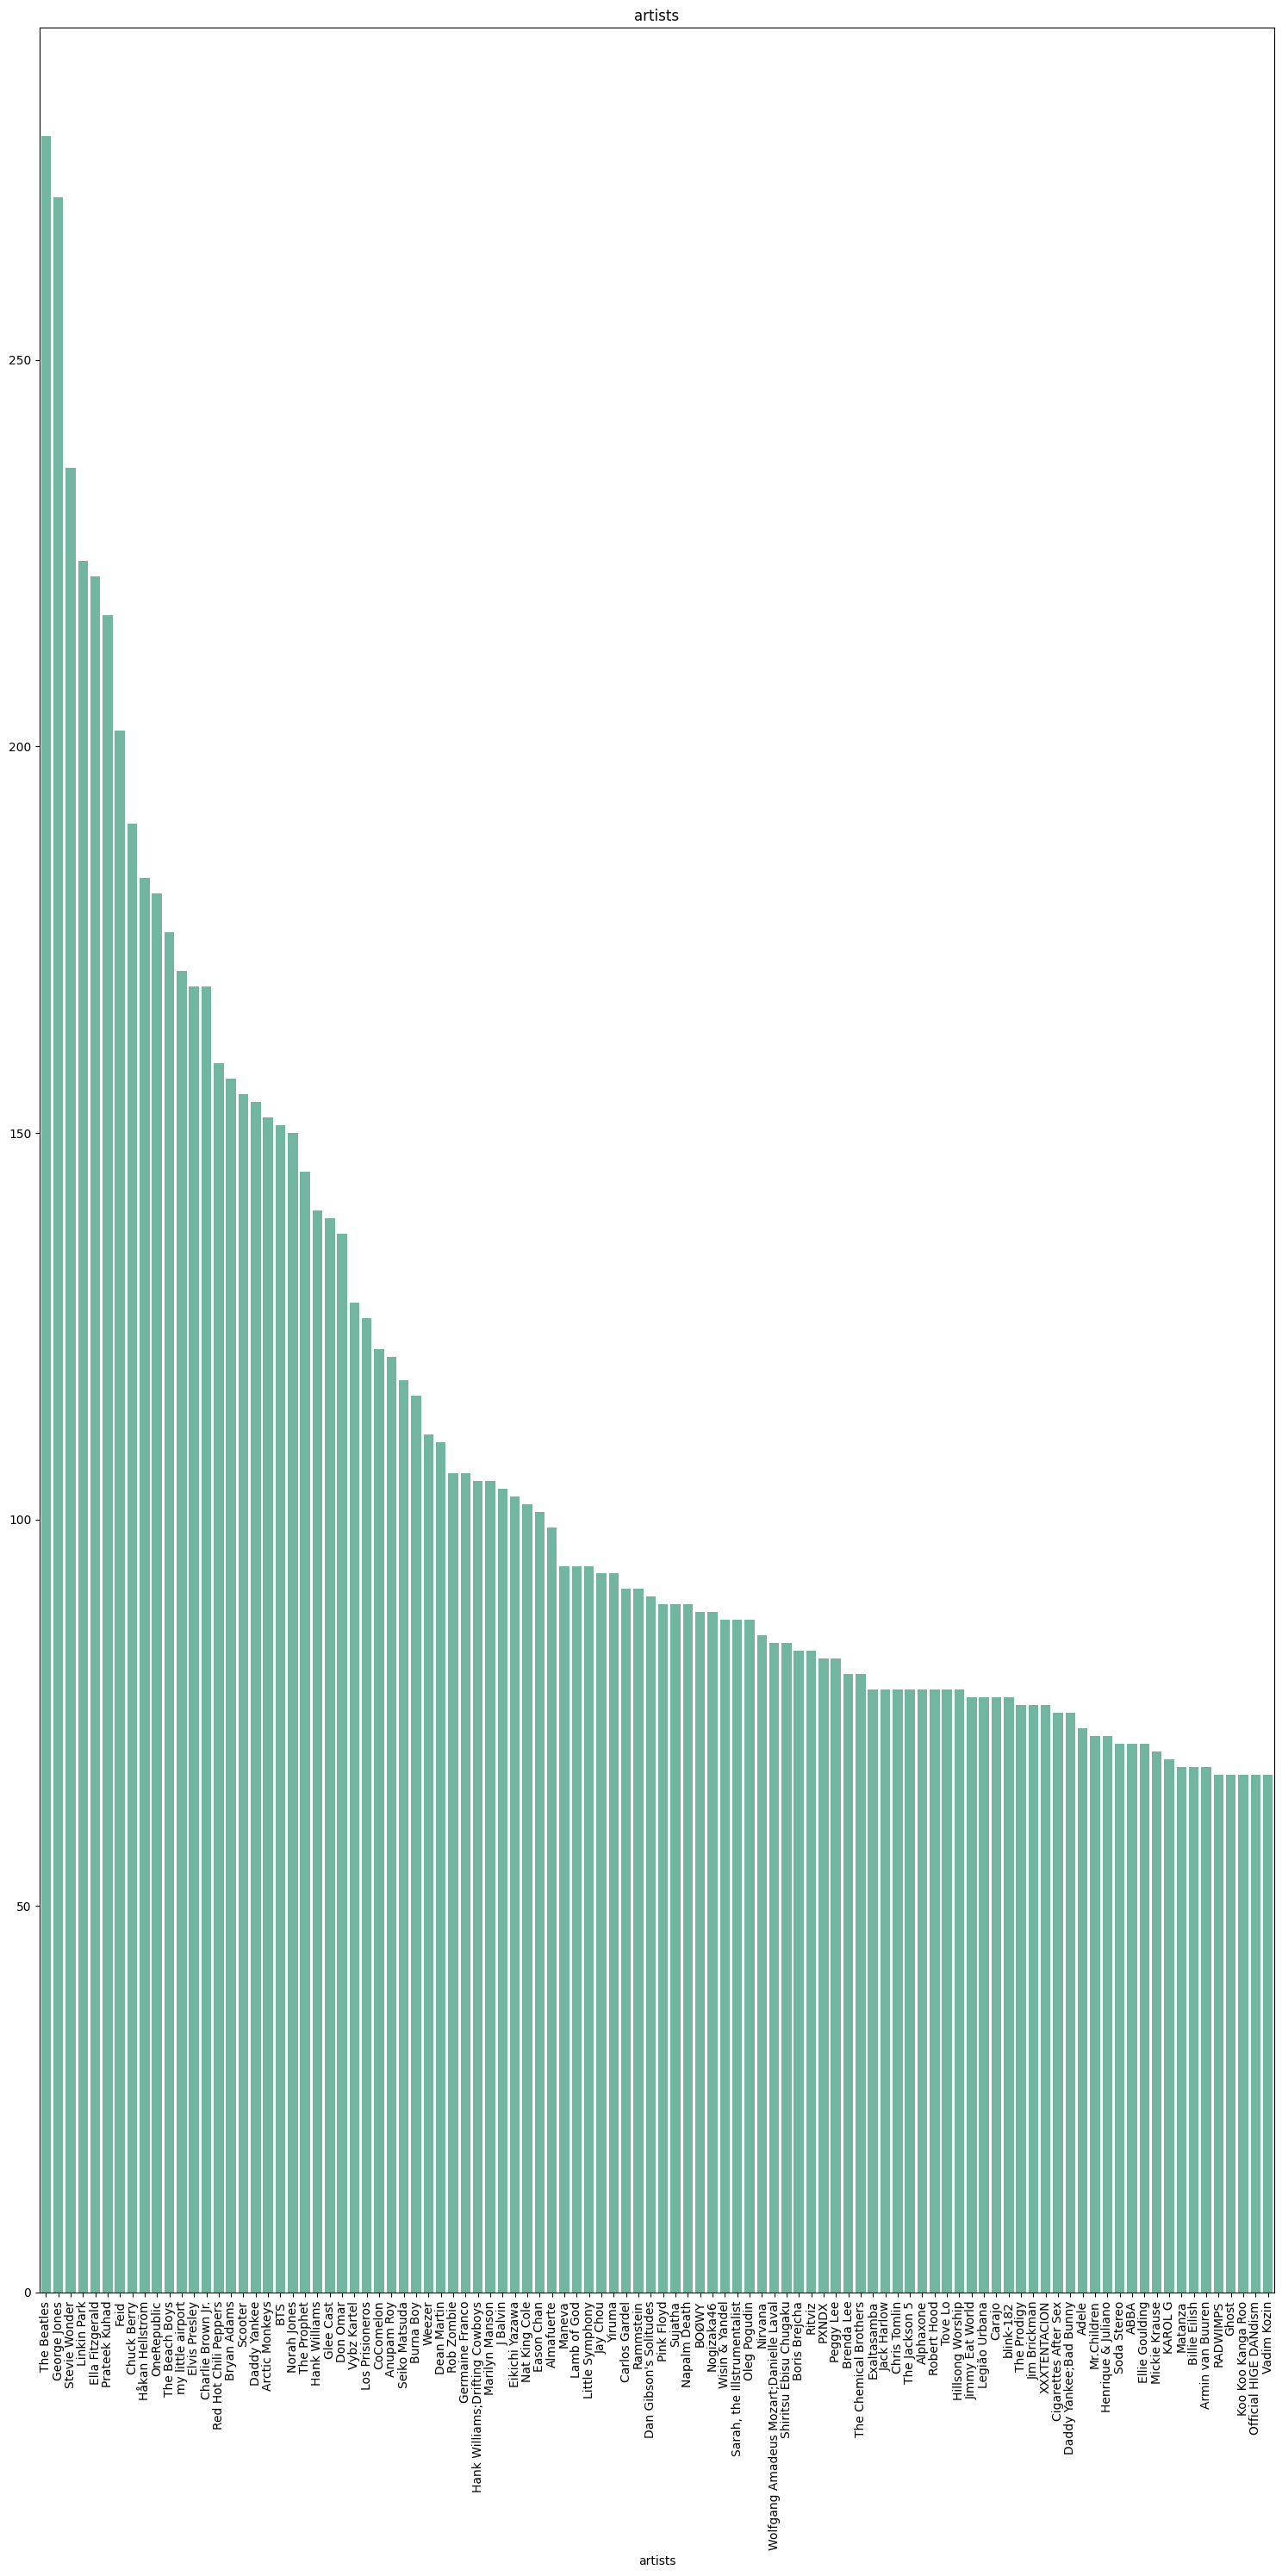

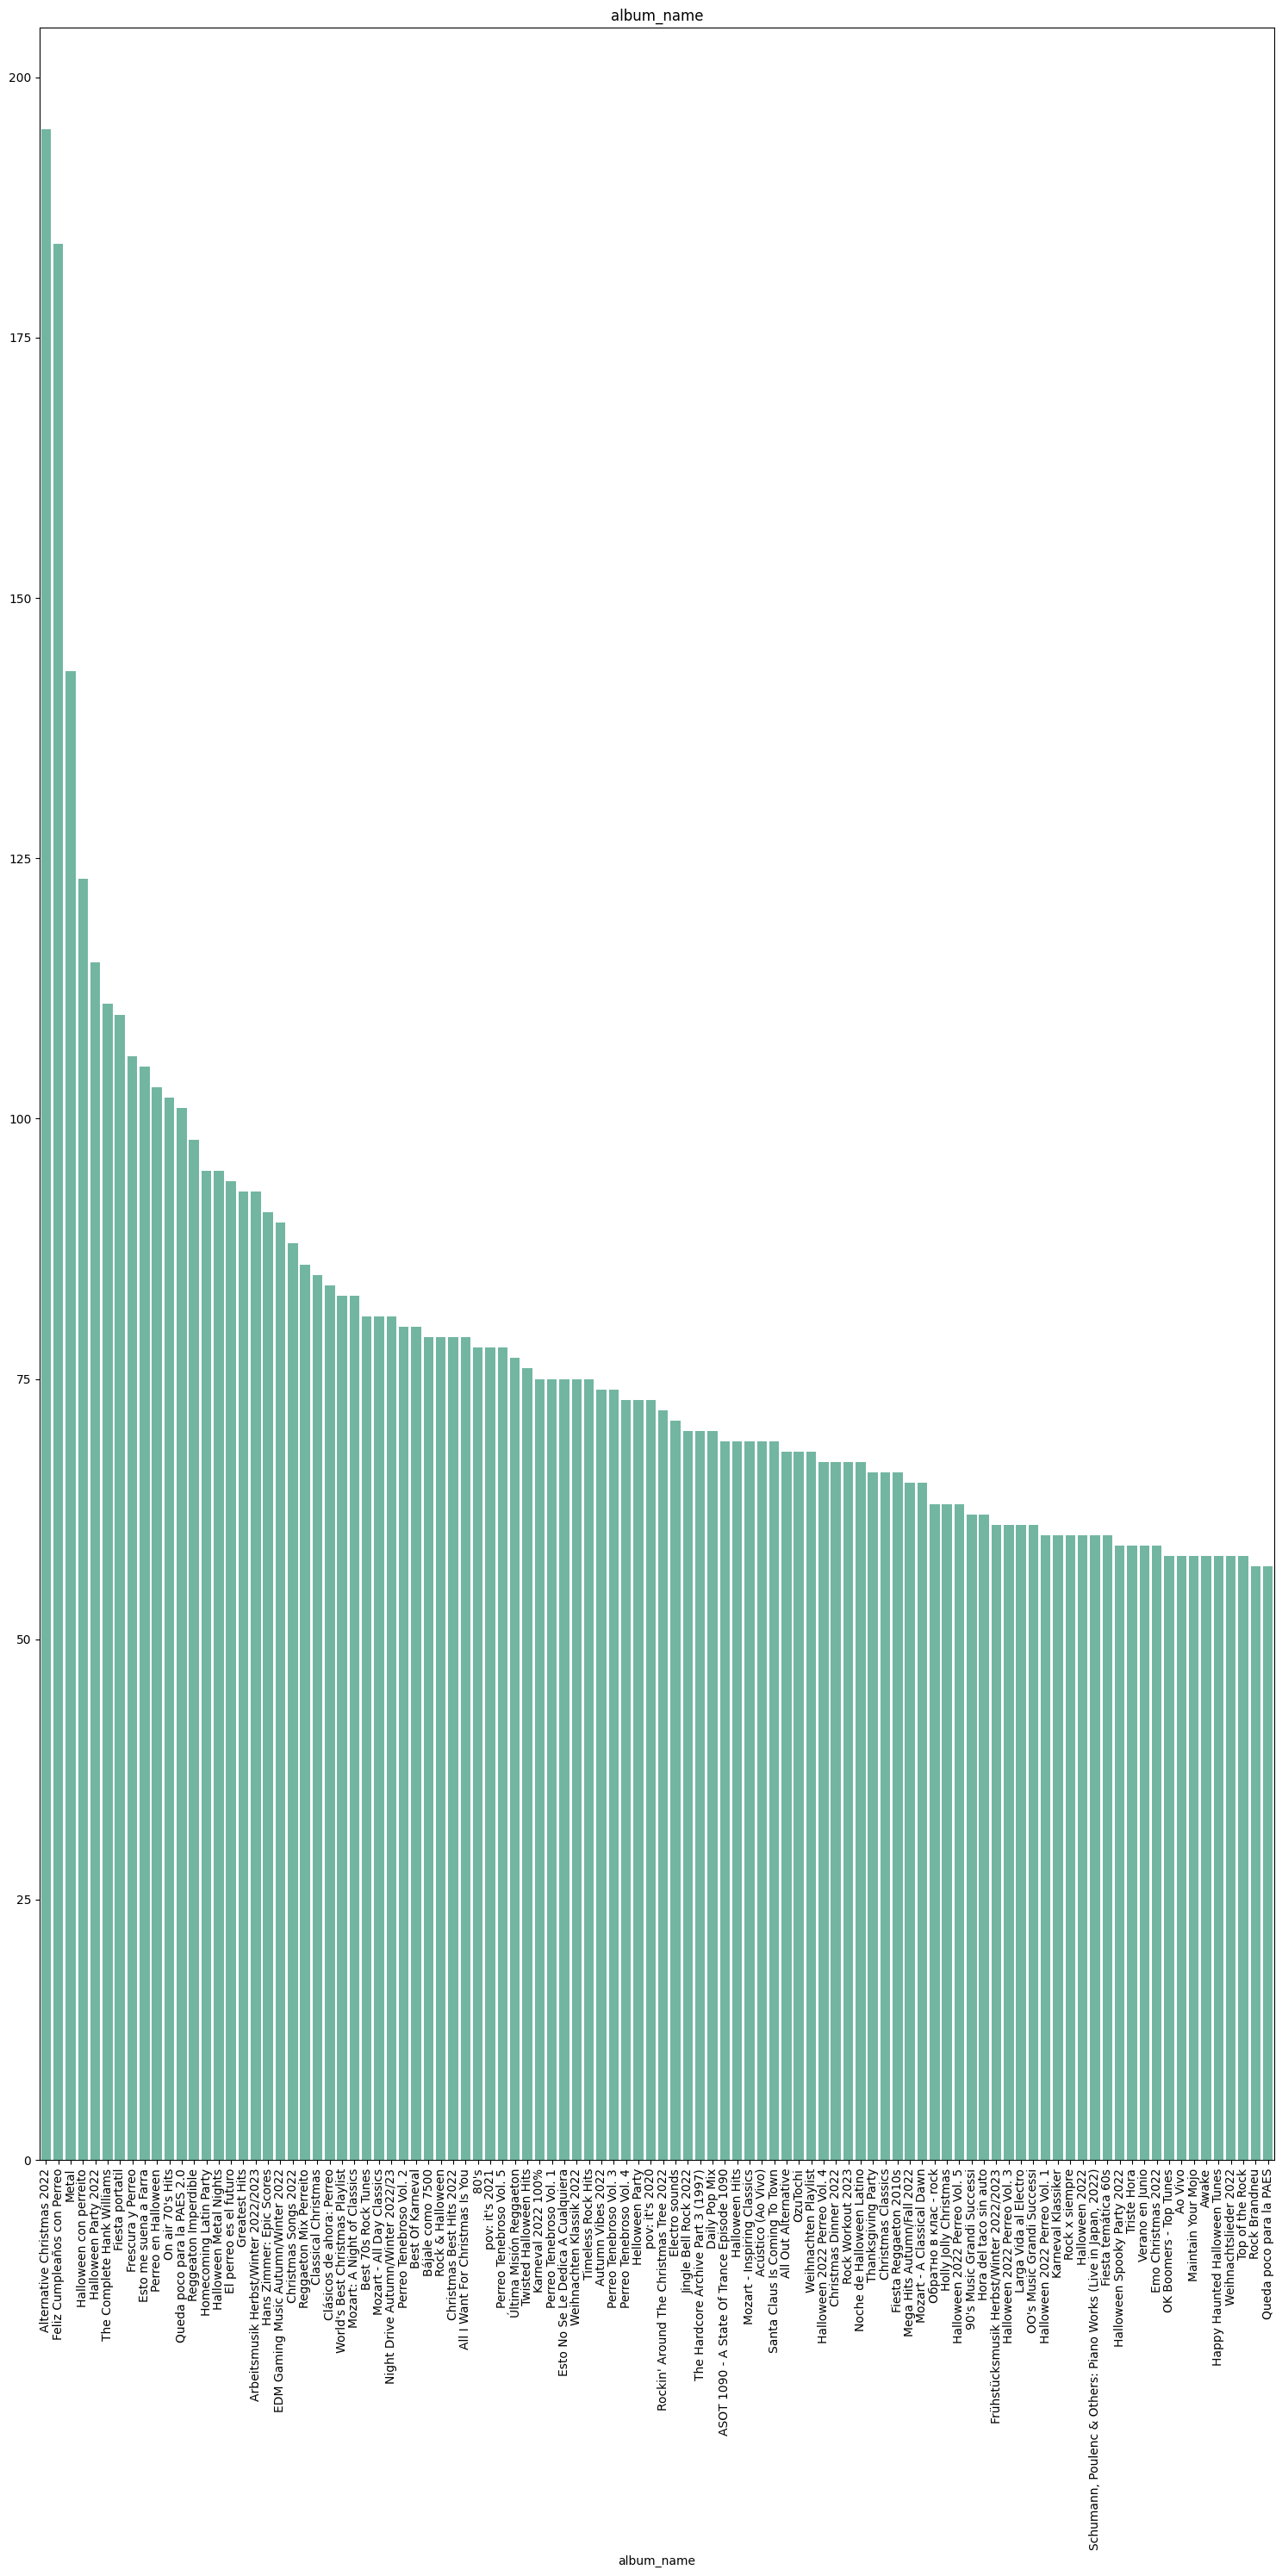

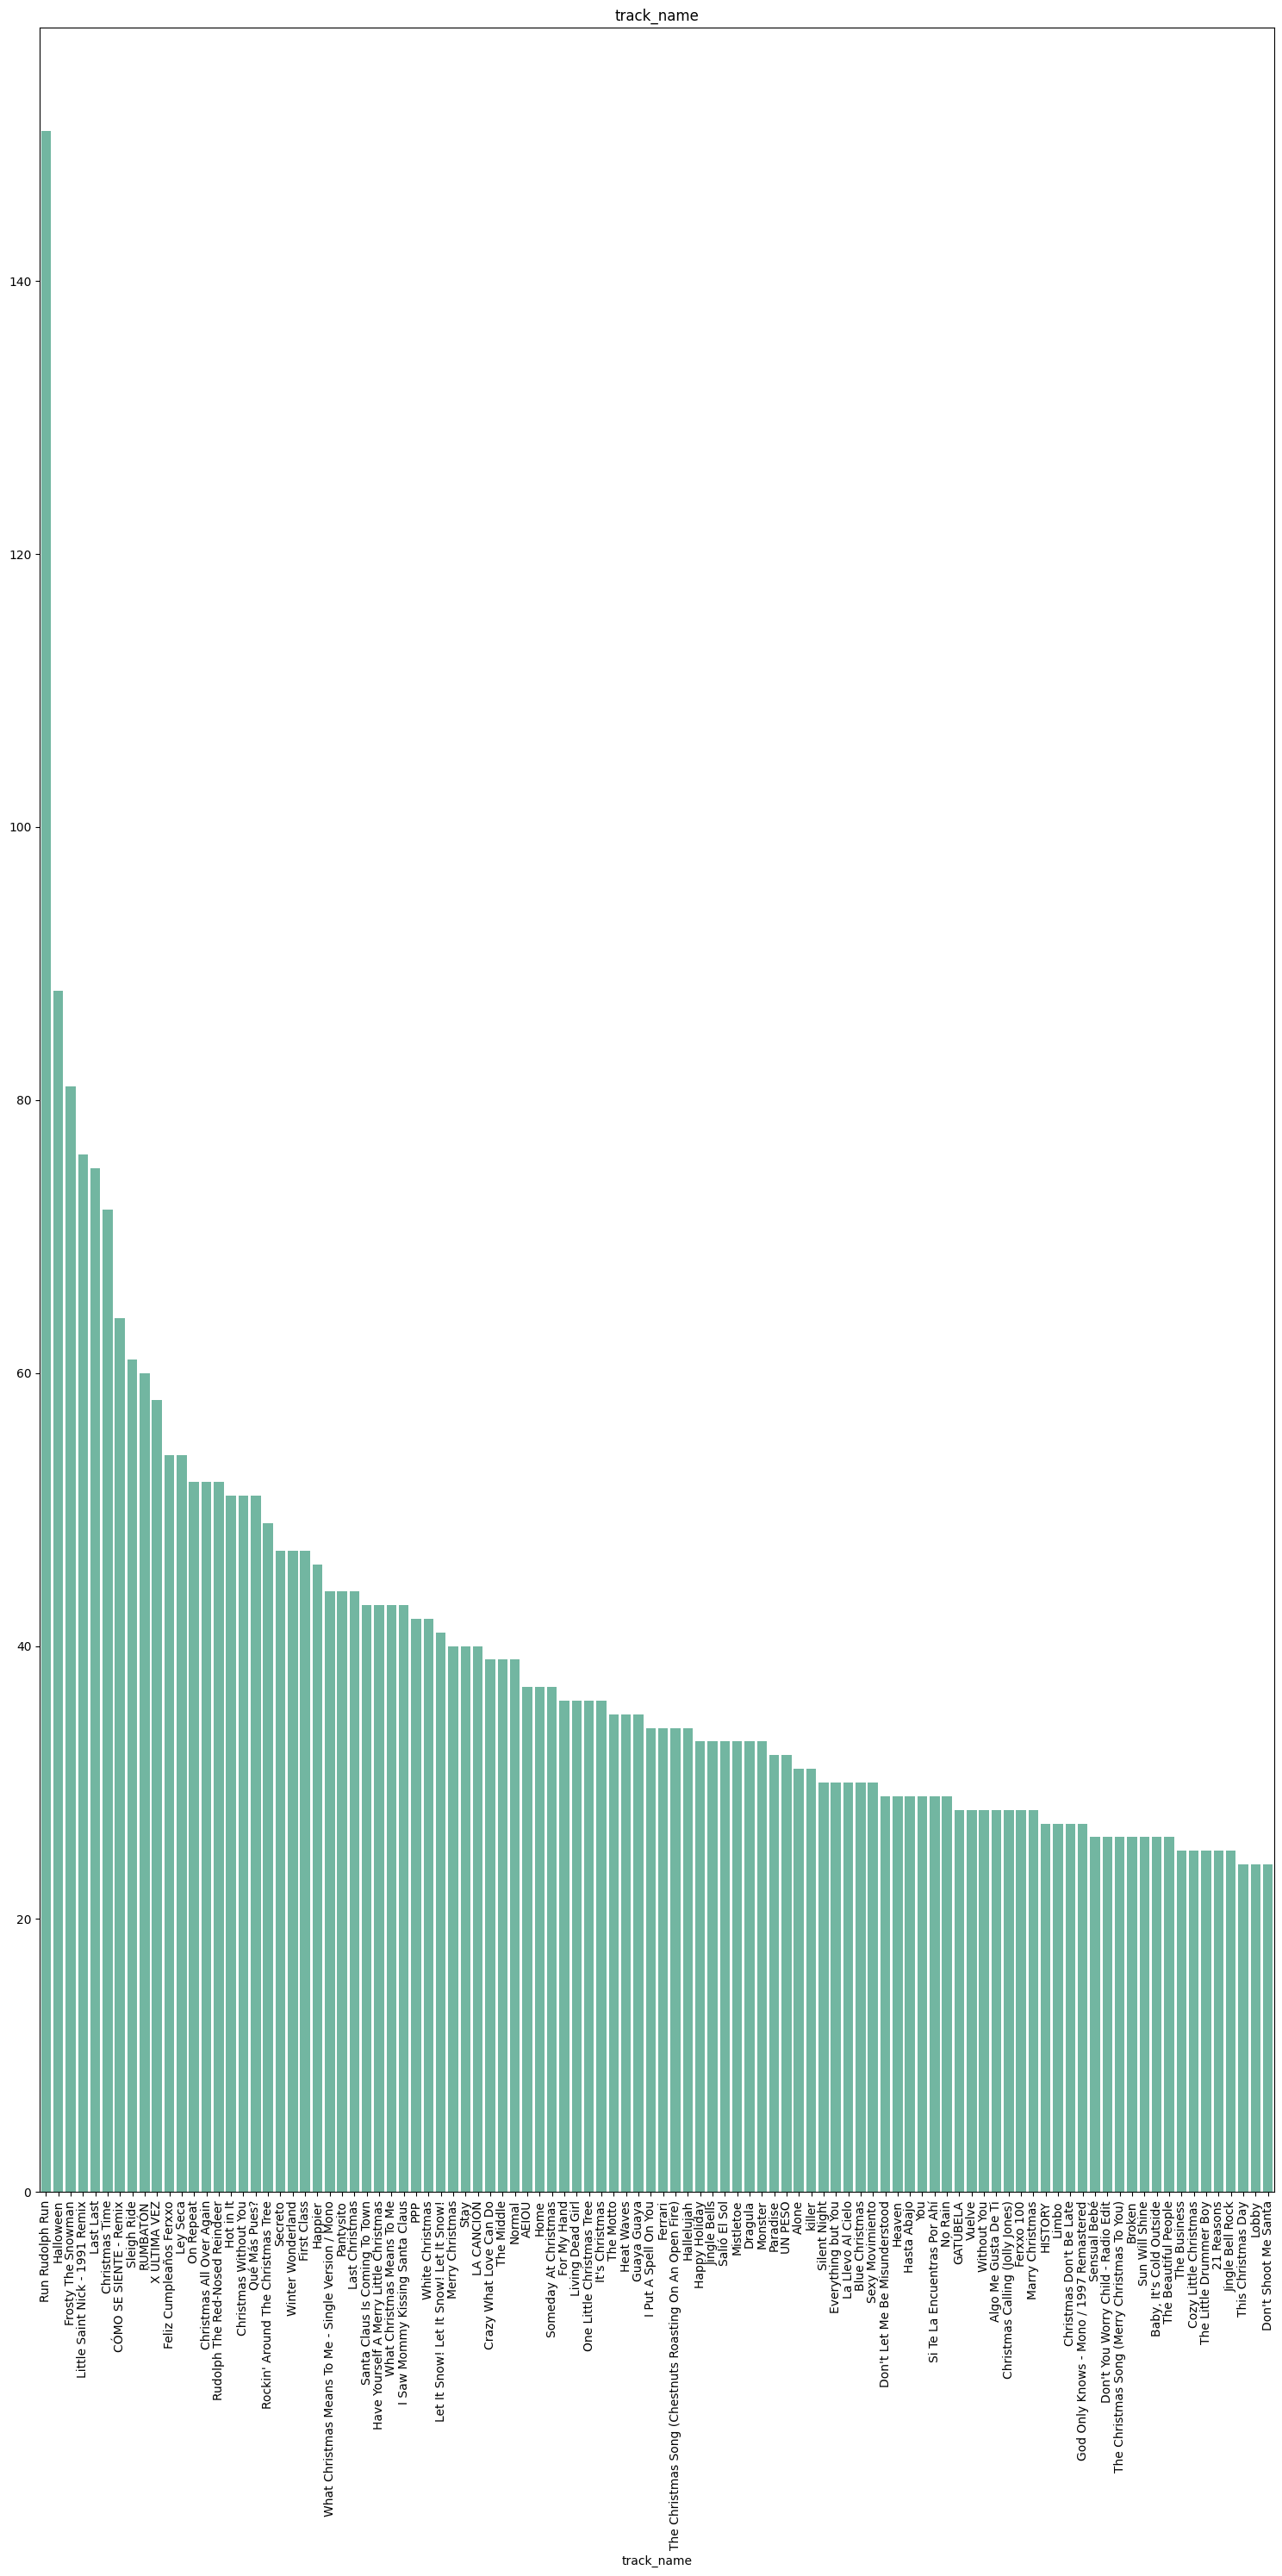

In [97]:
#one hot map ['artists','album_name','track_name']

targetFeatures=['artists','album_name','track_name']
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_palette('Set2')

for target in targetFeatures:
    
 
    plt.figure(figsize=(15,30))

    plt.title(f"{target}")

    newDf=dataset[target].value_counts().sort_values(ascending=False)

    sns.barplot(x=newDf[:100].index,y=newDf[:100].values)

    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

    

In [98]:
# making kendall's for all features
from scipy.stats import kendalltau

from sklearn.preprocessing import LabelEncoder
categoricals=dataset.select_dtypes(np.object_).columns
print(dataset[categoricals])

# encodedDataset=encoder.fit_transform(dataset[categoricals])
# encodedDataset
# encodedDataset.corr(method='kendall')

for categorical in categoricals:
    encoder=LabelEncoder()
    encodedDataset=encoder.fit_transform(dataset[categorical])
    dataset[categorical]=encodedDataset
    print(categorical)
    print(encodedDataset)
    

                       artists  \
0                  Gen Hoshino   
1                 Ben Woodward   
2       Ingrid Michaelson;ZAYN   
3                 Kina Grannis   
4             Chord Overstreet   
...                        ...   
113995           Rainy Lullaby   
113996           Rainy Lullaby   
113997           Cesária Evora   
113998        Michael W. Smith   
113999           Cesária Evora   

                                               album_name  \
0                                                  Comedy   
1                                        Ghost (Acoustic)   
2                                          To Begin Again   
3       Crazy Rich Asians (Original Motion Picture Sou...   
4                                                 Hold On   
...                                                   ...   
113995  #mindfulness - Soft Rain for Mindful Meditatio...   
113996  #mindfulness - Soft Rain for Mindful Meditatio...   
113997                                    

<Axes: >

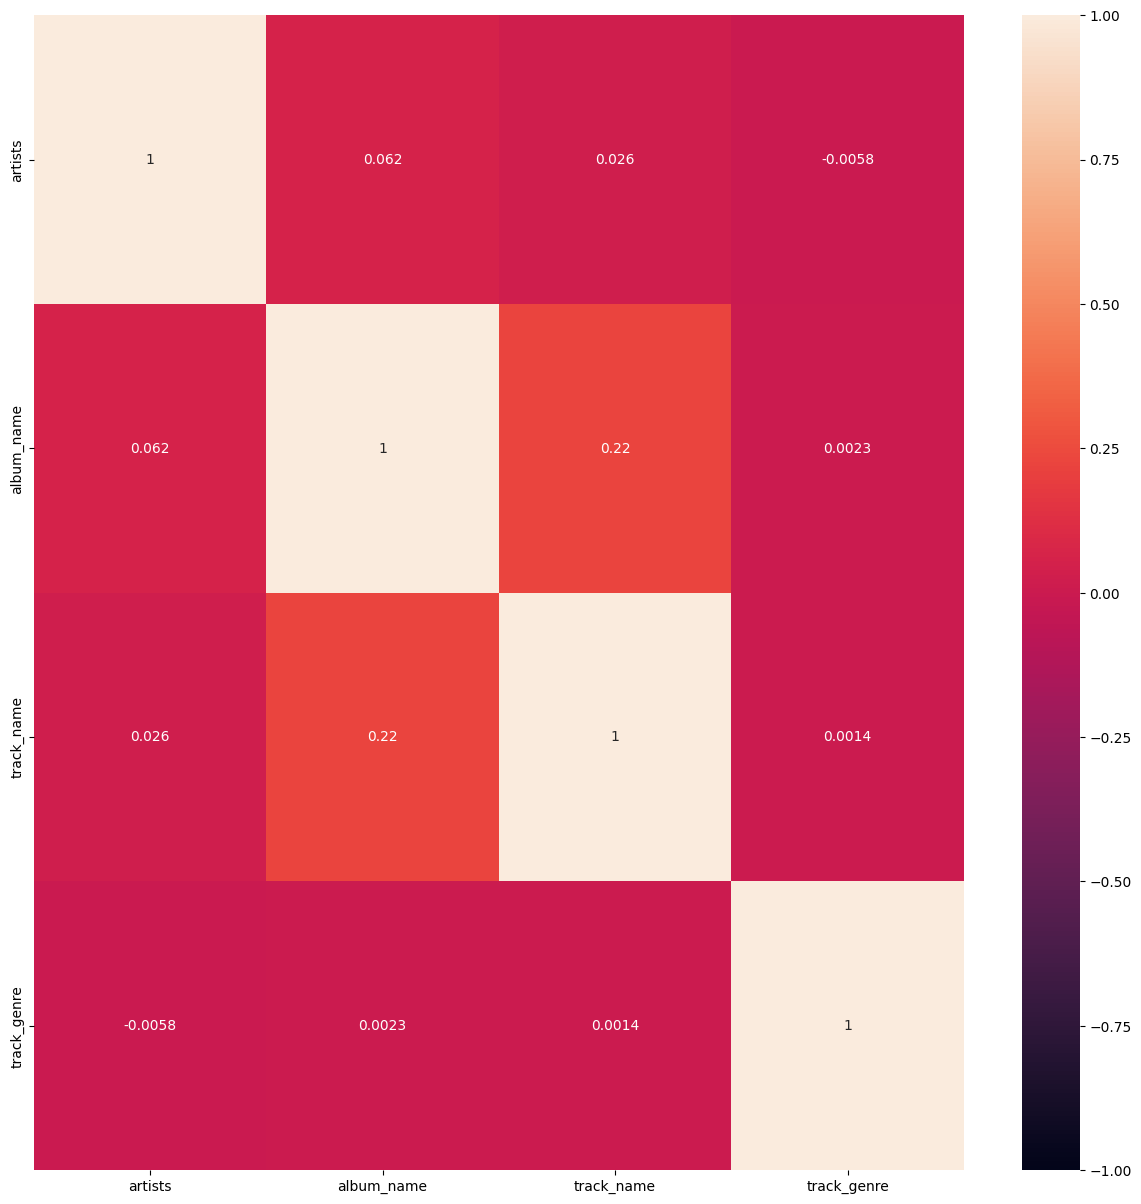

In [99]:
kendall=dataset[categoricals].corr(method='kendall')

#heatmap for kendall statistical test
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_palette('Set2')
plt.figure(figsize=(15,15))
sns.heatmap(kendall,vmax=1.,vmin=-1.,annot=True)

In [100]:
droppedFeatures=dataset.select_dtypes(np.object_).columns
targetCol=dataset['track_name']


selectedCols=dataset.drop(columns=droppedFeatures)



X=selectedCols
Y=targetCol

In [101]:
#Interpretation above graphs

# print(X)
print(X.explicit.value_counts())
print(X.key.value_counts())
print(X['mode'].value_counts())
print(f"Mean:\t{X.duration_s.mean()},\nMedian:\t{X.duration_s.median()}\n,Mode:\t{X.duration_s.mode()}")


print("target features length:\t",Y.shape[0])
print("selected cols length:\t",X.shape[0])


explicit
0    104252
1      9747
Name: count, dtype: int64
key
7.0     13244
0.0     13061
2.0     11644
9.0     11313
1.0     10772
5.0      9368
11.0     9282
4.0      9008
6.0      7921
10.0     7456
8.0      7360
3.0      3570
Name: count, dtype: int64
mode
1.0    72681
0.0    41318
Name: count, dtype: int64
Mean:	3800.51922312184,
Median:	3548.4333333333334
,Mode:	0    2714.95
Name: duration_s, dtype: float64
target features length:	 113999
selected cols length:	 113999


In [102]:
# print(X.isna().any()) #checking NaN values 
#return duration_s
#interpolate current feature
X.duration_s=(X.duration_s.interpolate(method='linear')).bfill().ffill()

print(X['duration_s'].isna().sum())
print(X[X['duration_s'].isna()])

#filling remained NaN values in duration_s feature


0
Empty DataFrame
Columns: [artists, album_name, track_name, popularity, explicit, danceability, energy, key, loudness, mode, speechiness, acousticness, instrumentalness, liveness, valence, tempo, track_genre, duration_s]
Index: []


In [103]:
Y.value_counts()
# print("Max Value:\t",Y.value_counts().values.max())
# print("Min Value:/t",Y.value_counts().values.min())


track_name
49965    151
24111     88
21601     81
34132     76
32863     75
        ... 
55037      1
24098      1
31677      1
19376      1
13194      1
Name: count, Length: 73608, dtype: int64

In [104]:
#model training
def training(model,X,Y,fitting=False):
    from sklearn.model_selection import KFold,cross_val_score

    if fitting:
        from sklearn.model_selection import train_test_split
        X_train,X_test,y_train,y_test=train_test_split(X,Y,test_size=0.3,random_state=42)


        return (model.fit(X_train,y_train),X_test,y_test,X_train,y_train)

In [105]:
#parameter tuning for clustering 
from sklearn.cluster import KMeans
import time 

wcss=[]

for n_cluster in range(1,11):
    model=KMeans(n_clusters=n_cluster,init='k-means++',random_state=42)
    inertia_=model.fit(dataset.track_name.value_counts().values.reshape(-1,1))
    wcss.append(model.inertia_)
    time.sleep(0.5)


print(wcss)
print("Completed")


[327225.20148632646, 161454.98281191182, 96022.24577839136, 59665.22185164762, 42795.05643565656, 29354.465064767104, 21338.881262791187, 15519.09307745928, 10793.50660480004, 8668.117294906373]
Completed


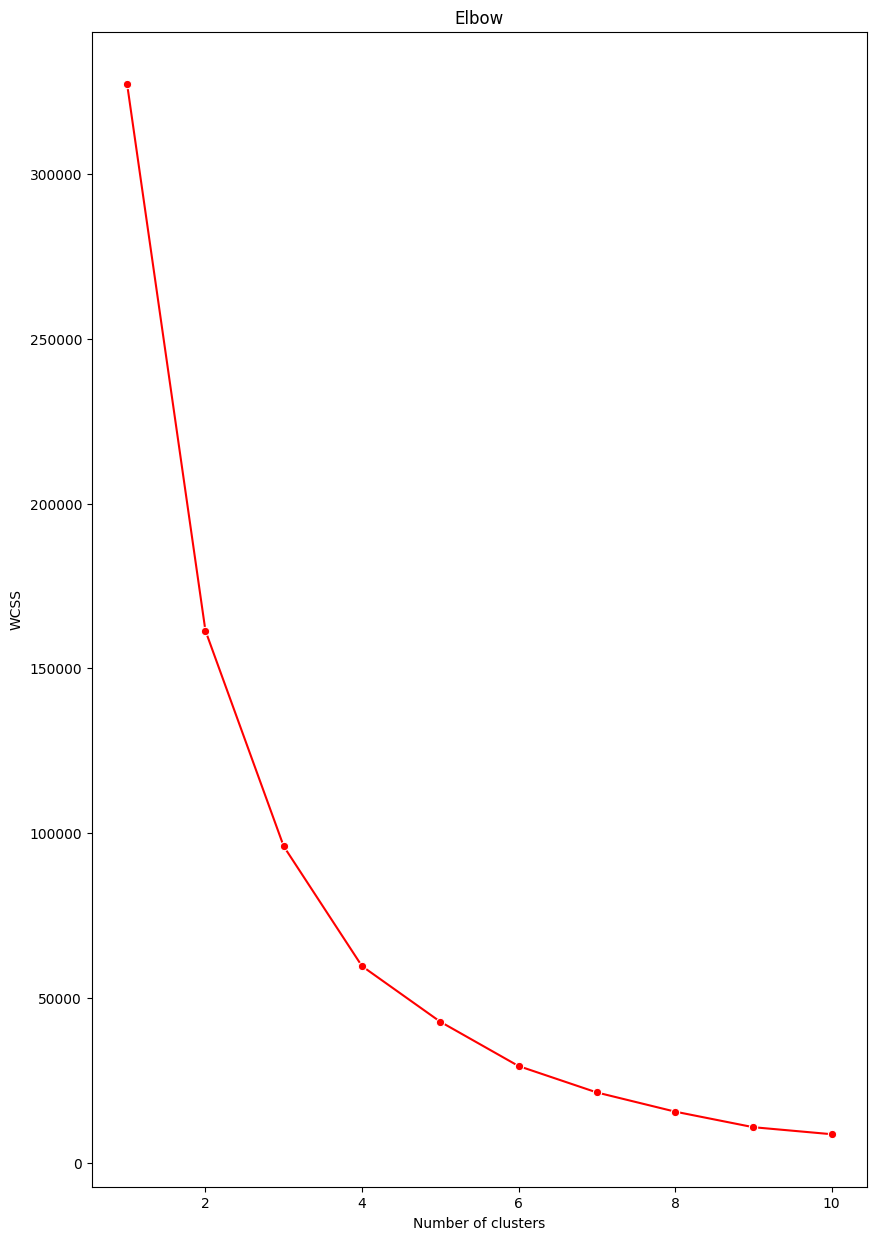

In [106]:
#Implementation Elbow method
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_palette('Set3')
plt.figure(figsize=(10,15))
sns.lineplot(x=range(1,11),y=wcss,marker='o',color='red')

plt.title('Elbow')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [114]:
##implementation cluster
n_cluster=1000
#importing required libraries
from sklearn.cluster import KMeans

kmeans=KMeans(n_clusters=n_cluster,random_state=42)
counts=dataset['track_name'].value_counts()
dataset['track_frequency']=dataset['track_name'].map(counts)

curr=counts.values.reshape(-1,1)


kmeans.fit(curr)
labels=kmeans.predict(curr)


In [115]:
print(dataset['track_name'])

0         11741
1         22528
2         60774
3          9580
4         25689
          ...  
113995    53329
113996    65090
113997    38207
113998    21507
113999     5999
Name: track_name, Length: 113999, dtype: int64


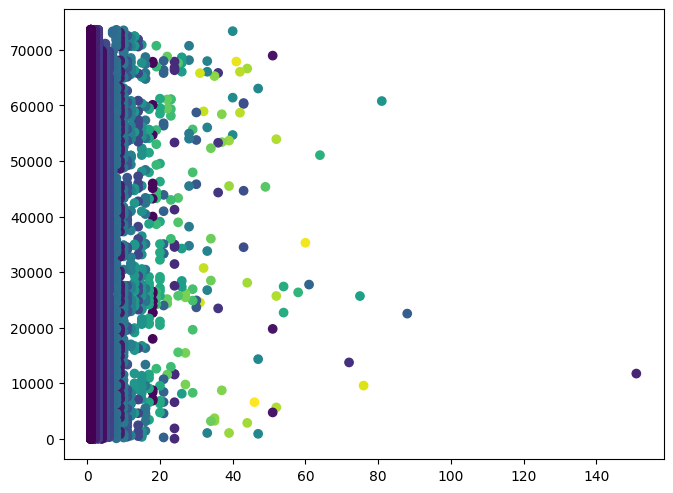

In [116]:
#visualizing current dataset(scatter plot)
import matplotlib.pyplot as plt
import seaborn as sns

fig=plt.figure(figsize=(15,15))
fig.add_axes([0.45, 0.45, 0.4, 0.3])

plt.scatter(curr,dataset['track_name'].unique(),c=labels)

plt.show()

In [117]:
#validation current model's as using silhouette score
from sklearn.metrics import silhouette_score

score=silhouette_score(curr,kmeans.labels_,metric='euclidean')
print(score)


0.9998233887620911
